# Install & Import Dependencies

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer
import umap
from sklearn.ensemble import RandomForestClassifier
import shap

# Data Preparation

## Read Data

In [2]:
current_path = os.getcwd()
excel_path = os.path.join(current_path, 'data.xlsx')

# Read 2 sheets dan gabungkan
df1 = pd.read_excel(excel_path, sheet_name='Year 2009-2010')
df2 = pd.read_excel(excel_path, sheet_name='Year 2010-2011')
df_combine = pd.concat([df1, df2], ignore_index=True)

df = df_combine.copy()
display(df.head())
display(df.info())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


None

## Data Cleaning

### Handle Missing Values

In [3]:
missing_data = df.isnull().sum()
print(f"Missing data count:\n{missing_data}")

df = df.dropna(subset=['Customer ID', 'Description'])

print(f"\nJumlah Missing Value setelah dihapus: {df.isnull().sum().sum()}")
print(f"Jumlah data setelah hapus missing value: {df.shape[0]}")

Missing data count:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Jumlah Missing Value setelah dihapus: 0
Jumlah data setelah hapus missing value: 824364


### Handle Duplicate Data

In [4]:
duplicate_rows = df[df.duplicated(keep='first')]
duplicate_rows_sorted = duplicate_rows.sort_values(by=['Invoice', 'StockCode', 'Description', 'Customer ID', 'Quantity'])
display(duplicate_rows_sorted.head(10))

print(f"Jumlah data duplikat: {duplicate_rows.shape[0]}")

df = df.drop_duplicates()
print(f"Jumlah data setelah hapus duplikasi: {df.shape[0]}")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


Jumlah data duplikat: 26479
Jumlah data setelah hapus duplikasi: 797885


### Handle Cancelled Transactions

In [5]:
# Ambil yang invoice nya tidak ada simbol C, Quantity & Price > 0
df_clean = df[
    (~df['Invoice'].astype(str).str.startswith('C')) &  
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
]

print(f"Jumlah data setelah hapus data cancel & anomali: {df_clean.shape[0]}")

Jumlah data setelah hapus data cancel & anomali: 779425


### Refactor & Handle Stock Codes

In [6]:
# print(f"Jumlah stock code unik: {df_clean['StockCode'].nunique()}")

df_clean["StockCodeNumberCount"] = df_clean["StockCode"].astype(str).str.count(r"\d")
print(df_clean["StockCodeNumberCount"].value_counts())


# Numeric Character untuk transaksi yang valid adalah 5 
df_clean = df_clean[df_clean["StockCodeNumberCount"] == 5]
df_clean = df_clean.drop(columns=['StockCodeNumberCount'])
print(f"Jumlah data setelah hapus stock code anomali: {df_clean.shape[0]}")


# Gabungkan StockCode produk yang hanya beda tipe
df_clean.reset_index(drop=True, inplace=True)
df_clean['StockCode'] = df_clean['StockCode'].astype(str).apply(lambda x: x[:-1] if len(x) == 6 else x)
display(df_clean.head())

StockCodeNumberCount
5    776577
0      2585
1       251
3        10
4         2
Name: count, dtype: int64
Jumlah data setelah hapus stock code anomali: 776577


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Cleaning Unrealistic Data (Noise)

In [7]:
# Quantity
# Mean = 13.5, Median (50%) = 6, tapi Max = 80,995 (outlier extreme & tidak masuk akal, bisa menarik centroid kalau dibiarkan)

# Price
# walau skewed extreme, tapi masih valid karena memang datanya bukan berasal dari perilaku konsumen

print("Data sebelum winsorize:")
display(df_clean.describe())

# Winsorize Quantity top 0.001% 
df_clean['Quantity'] = winsorize(df_clean['Quantity'], limits=(0, 0.001)) # winsor 0.001% saja dampaknya sudah signifikan

print("Data setelah winsorize:")
display(df_clean.describe())

Data sebelum winsorize:


,Quantity,InvoiceDate,Price,Customer ID
count,776577.000000,776577,776577.000000,776577.000000
mean,13.519243,2011-01-03 00:44:11.290393600,2.934561,15326.605797
min,1.000000,2009-12-01 07:45:00,0.030000,12346.000000
25%,2.000000,2010-07-02 14:15:00,1.250000,13979.000000
50%,6.000000,2010-12-02 13:49:00,1.950000,15253.000000
75%,12.000000,2011-08-01 13:31:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,146.096695,NaN,4.293610,1692.861742


Data setelah winsorize:


,Quantity,InvoiceDate,Price,Customer ID
count,776577.000000,776577,776577.000000,776577.000000
mean,12.457567,2011-01-03 00:44:11.290393600,2.934561,15326.605797
min,1.000000,2009-12-01 07:45:00,0.030000,12346.000000
25%,2.000000,2010-07-02 14:15:00,1.250000,13979.000000
50%,6.000000,2010-12-02 13:49:00,1.950000,15253.000000
75%,12.000000,2011-08-01 13:31:00,3.750000,16795.000000
max,576.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,32.867586,NaN,4.293610,1692.861742


## Data Transformation

### Refactor Customer ID Data Type

In [8]:
# Biar rapi aja liatnya
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

### Add RFM Features

In [9]:
# Recency: hari sejak pembelian terakhir
def getRecency(df):
    reference_date = df['InvoiceDate'].max()
    last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()
    return (reference_date - last_purchase).dt.days.to_frame(name='Recency')

# Frequency: jumlah transaksi unik
def getFrequency(df):
    return df.groupby('Customer ID')['Invoice'].nunique().to_frame(name='Frequency')

# Monetary: total pengeluaran
def getMonetary(df):
    df = df.copy()
    df['Total_Price'] = df['Price'] * df['Quantity']
    return df.groupby('Customer ID')['Total_Price'].sum().to_frame(name='Monetary')


# Customer ID jadikan index, ambil RFM
customer_data = (df_clean['Customer ID'].drop_duplicates().sort_values().to_frame(name = 'Customer_ID').set_index('Customer_ID')
                 .join(getRecency(df_clean))
                 .join(getFrequency(df_clean))
                 .join(getMonetary(df_clean))
)

display(customer_data.head())

,Recency,Frequency,Monetary
Customer_ID,,,
12346,325,3,768.40
12347,1,8,4921.53
12348,74,5,1658.40
12349,18,3,3678.69
12350,309,1,294.40


### Add Product Related Features

In [10]:
# Total produk yang dibeli
def getTotalProductsPurchased(df):
    return df.groupby('Customer ID')['StockCode'].count().to_frame(name='Total_Products_Purchased')

# Total produk unik yang dibeli
def getTotalDistinctProductsPurchased(df):
    return df.groupby('Customer ID')['StockCode'].nunique().to_frame(name='Total_Distinct_Products_Purchased')

# Total Quantity dari tiap produk yang dibeli
def getTotalProductQuantityPurchased(df):
    return df.groupby('Customer ID')['Quantity'].sum().to_frame(name='Total_Product_Quantity_Purchased')

# Konsistensi pengeluaran transaksi (Makin tinggi angkanya, artinya jumlah pengeluaran pelanggan tidak konsisten, kadang beli sedikit, kadang banyak)
def getCVSpending(df):
    df_copy = df.copy()
    df_copy['Total_Price'] = df_copy['Price'] * df_copy['Quantity']
    transaction_spending = df_copy.groupby(['Customer ID','Invoice'])['Total_Price'].sum()
    metrics = transaction_spending.groupby('Customer ID').agg(['mean','std'])
    cv_spending = (metrics['std']/metrics['mean']).fillna(0).to_frame(name='CV_Spending')
    return cv_spending


customer_data = (customer_data
                 .join(getTotalProductsPurchased(df_clean))
                .join(getTotalDistinctProductsPurchased(df_clean))
                .join(getTotalProductQuantityPurchased(df_clean))
                .join(getCVSpending(df_clean))
)

display(customer_data.head())

,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending
Customer_ID,,,,,,,
12346,325,3,768.40,25,24,600,1.181049
12347,1,8,4921.53,222,119,2967,0.513293
12348,74,5,1658.40,46,24,2704,0.563974
12349,18,3,3678.69,172,136,1621,0.166930
12350,309,1,294.40,16,16,196,0.000000


### Add Average Related Features

In [11]:
# Rata-rata spending per transaksi
def getAverageTransactionSpending(df):
    return (df['Monetary'] / (df['Frequency']+1)).to_frame(name='Average_Spending_Per_Transaction')

# Rata-rata total quantity product per transaksi
def getAverageQuantityPerTransaction(df):
    return (df['Total_Product_Quantity_Purchased'] / (df['Frequency']+1)).to_frame(name='Average_Total_Product_Quantity_Per_Transaction')

# Rata-rata jumlah item yang dibeli per transaksi
def getAverageItemCountPerTransaction(df):
    return (df['Total_Products_Purchased'] / (df['Frequency']+1)).to_frame(name='Average_Item_Count_Per_Transaction')


customer_data = (
    customer_data
    .join(getAverageTransactionSpending(customer_data))
    .join(getAverageQuantityPerTransaction(customer_data))
    .join(getAverageItemCountPerTransaction(customer_data))
)

display(customer_data.head())

,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending,Average_Spending_Per_Transaction,Average_Total_Product_Quantity_Per_Transaction,Average_Item_Count_Per_Transaction
Customer_ID,,,,,,,,,,
12346,325,3,768.40,25,24,600,1.181049,192.100000,150.000000,6.250000
12347,1,8,4921.53,222,119,2967,0.513293,546.836667,329.666667,24.666667
12348,74,5,1658.40,46,24,2704,0.563974,276.400000,450.666667,7.666667
12349,18,3,3678.69,172,136,1621,0.166930,919.672500,405.250000,43.000000
12350,309,1,294.40,16,16,196,0.000000,147.200000,98.000000,8.000000


### Add Maximum Related Features

In [12]:
# Maks Spending dari satu transaksi customer 
def getMaxSingleTransactionSpending(df):
    df = df.copy()
    df['Total_Price'] = df['Price'] * df['Quantity']
    customer_transaction_sum = df.groupby(['Customer ID', 'Invoice'])['Total_Price'].sum().to_frame(name = 'Sum')
    return customer_transaction_sum.groupby('Customer ID')['Sum'].max().to_frame(name = 'Max_Single_Transaction_Spending')

# Maks Item count dari satu transaksi customer
def getMaxSingleTransactionItemCount(df):
    customer_transaction_item_count = df.groupby(['Customer ID', 'Invoice'])['StockCode'].count().to_frame(name = 'Count')
    return customer_transaction_item_count.groupby(['Customer ID'])['Count'].max().to_frame(name = 'Max_Single_Transaction_Item_Count')

# Maks Quantity products dari satu transaksi customer
def getMaxSingleTransactionTotalQuantity(df):
    customer_transaction_total_quantity = df.groupby(['Customer ID', 'Invoice'])['Quantity'].sum().to_frame(name = 'Sum')
    return customer_transaction_total_quantity.groupby(['Customer ID'])['Sum'].max().to_frame(name = 'Max_Single_Transaction_Total_Quantity')


customer_data = (
    customer_data
    .join(getMaxSingleTransactionSpending(df_clean))
    .join(getMaxSingleTransactionItemCount(df_clean))
    .join(getMaxSingleTransactionTotalQuantity(df_clean))
)

display(customer_data.head())

,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending,Average_Spending_Per_Transaction,Average_Total_Product_Quantity_Per_Transaction,Average_Item_Count_Per_Transaction,Max_Single_Transaction_Spending,Max_Single_Transaction_Item_Count,Max_Single_Transaction_Total_Quantity
Customer_ID,,,,,,,,,,,,,
12346,325,3,768.40,25,24,600,1.181049,192.100000,150.000000,6.250000,599.04,19,576
12347,1,8,4921.53,222,119,2967,0.513293,546.836667,329.666667,24.666667,1294.32,47,676
12348,74,5,1658.40,46,24,2704,0.563974,276.400000,450.666667,7.666667,652.80,19,1248
12349,18,3,3678.69,172,136,1621,0.166930,919.672500,405.250000,43.000000,1457.55,72,630
12350,309,1,294.40,16,16,196,0.000000,147.200000,98.000000,8.000000,294.40,16,196


### Add Time Related Features

In [13]:
# Umur Pelanggan sejak pertama kali belanja sampai hari terakhir transaksi di dataset
def getCustomerTenure(df):
    reference_date = df['InvoiceDate'].max()
    customer_first_invoice_date = df.groupby('Customer ID')['InvoiceDate'].min()
    customer_lifetime = (reference_date - customer_first_invoice_date).dt.days
    
    return customer_lifetime.to_frame(name='Tenure')

# Rata-rata jangka waktu belanja
def getAverageTimeBetweenPurchases(df):
    customer_invoice_dates = df.groupby('Customer ID')['InvoiceDate'].apply(list)
    
    avg_time_between_purchases = customer_invoice_dates.apply(
        lambda dates: (pd.Series(dates).sort_values().diff().dt.days).mean()
    ).to_frame(name='Average_Time_Between_Purchases')
    
    # Isi nilai NaN dengan 0
    avg_time_between_purchases = avg_time_between_purchases.fillna(0)
    
    return avg_time_between_purchases

# Rata-rata spending berdasarkan umur pelanggan sejak pertama belanja (Monetary / Tenure)
def getMonetaryPerTenure(df):
    return (df['Monetary'] / (df['Tenure']+1)).to_frame(name='Monetary_Per_Tenure')



customer_data = (
    customer_data
    .join(getCustomerTenure(df_clean))
    .join(getAverageTimeBetweenPurchases(df_clean))
)

customer_data = (
    customer_data
    .join(getMonetaryPerTenure(customer_data))
)

display(customer_data.head())

,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending,Average_Spending_Per_Transaction,Average_Total_Product_Quantity_Per_Transaction,Average_Item_Count_Per_Transaction,Max_Single_Transaction_Spending,Max_Single_Transaction_Item_Count,Max_Single_Transaction_Total_Quantity,Tenure,Average_Time_Between_Purchases,Monetary_Per_Tenure
Customer_ID,,,,,,,,,,,,,,,,
12346,325,3,768.40,25,24,600,1.181049,192.100000,150.000000,6.250000,599.04,19,576,646,13.375000,1.187635
12347,1,8,4921.53,222,119,2967,0.513293,546.836667,329.666667,24.666667,1294.32,47,676,403,1.805430,12.182005
12348,74,5,1658.40,46,24,2704,0.563974,276.400000,450.666667,7.666667,652.80,19,1248,437,8.044444,3.786301
12349,18,3,3678.69,172,136,1621,0.166930,919.672500,405.250000,43.000000,1457.55,72,630,588,3.333333,6.245654
12350,309,1,294.40,16,16,196,0.000000,147.200000,98.000000,8.000000,294.40,16,196,309,0.000000,0.949677


## Data Normalization

In [14]:
# # Sebelum masuk ke seleksi fitur, outlier harus di handle dulu karena bisa sangat mempengaruhi distribusi dan korelasi data
# Kenapa pakai log transform? 

# Banyak metode statistik, termasuk analisis korelasi, berasumsi bahwa data memiliki distribusi normal atau setidaknya simetris.
# Data dengan fitur yang sangat miring (skewed) dan memiliki outlier ekstrem dapat melanggar asumsi ini

# Analisis korelasi mengukur hubungan linier antara dua variabel.
# Ketika data sangat miring (misalnya, Monetary), hubungan antara dua fitur bisa jadi tidak linier dan tidak akurat

# Fitur dengan rentang nilai yang sangat besar bisa mendominasi perhitungan korelasi, membuat fitur lain tampak tidak berkorelasi


# Log transform mengubah distribusi data menjadi lebih terdistribusi normal
# Dengan mengubah data ke skala logaritmik, sering kali dapat memperkuat hubungan linier antar fitur, yang memungkinkan analisis korelasi untuk memberikan hasil yang lebih akurat.

# Log transform menyamakan skala tiap fitur, memastikan setiap fitur memberikan kontribusi yang lebih seimbang

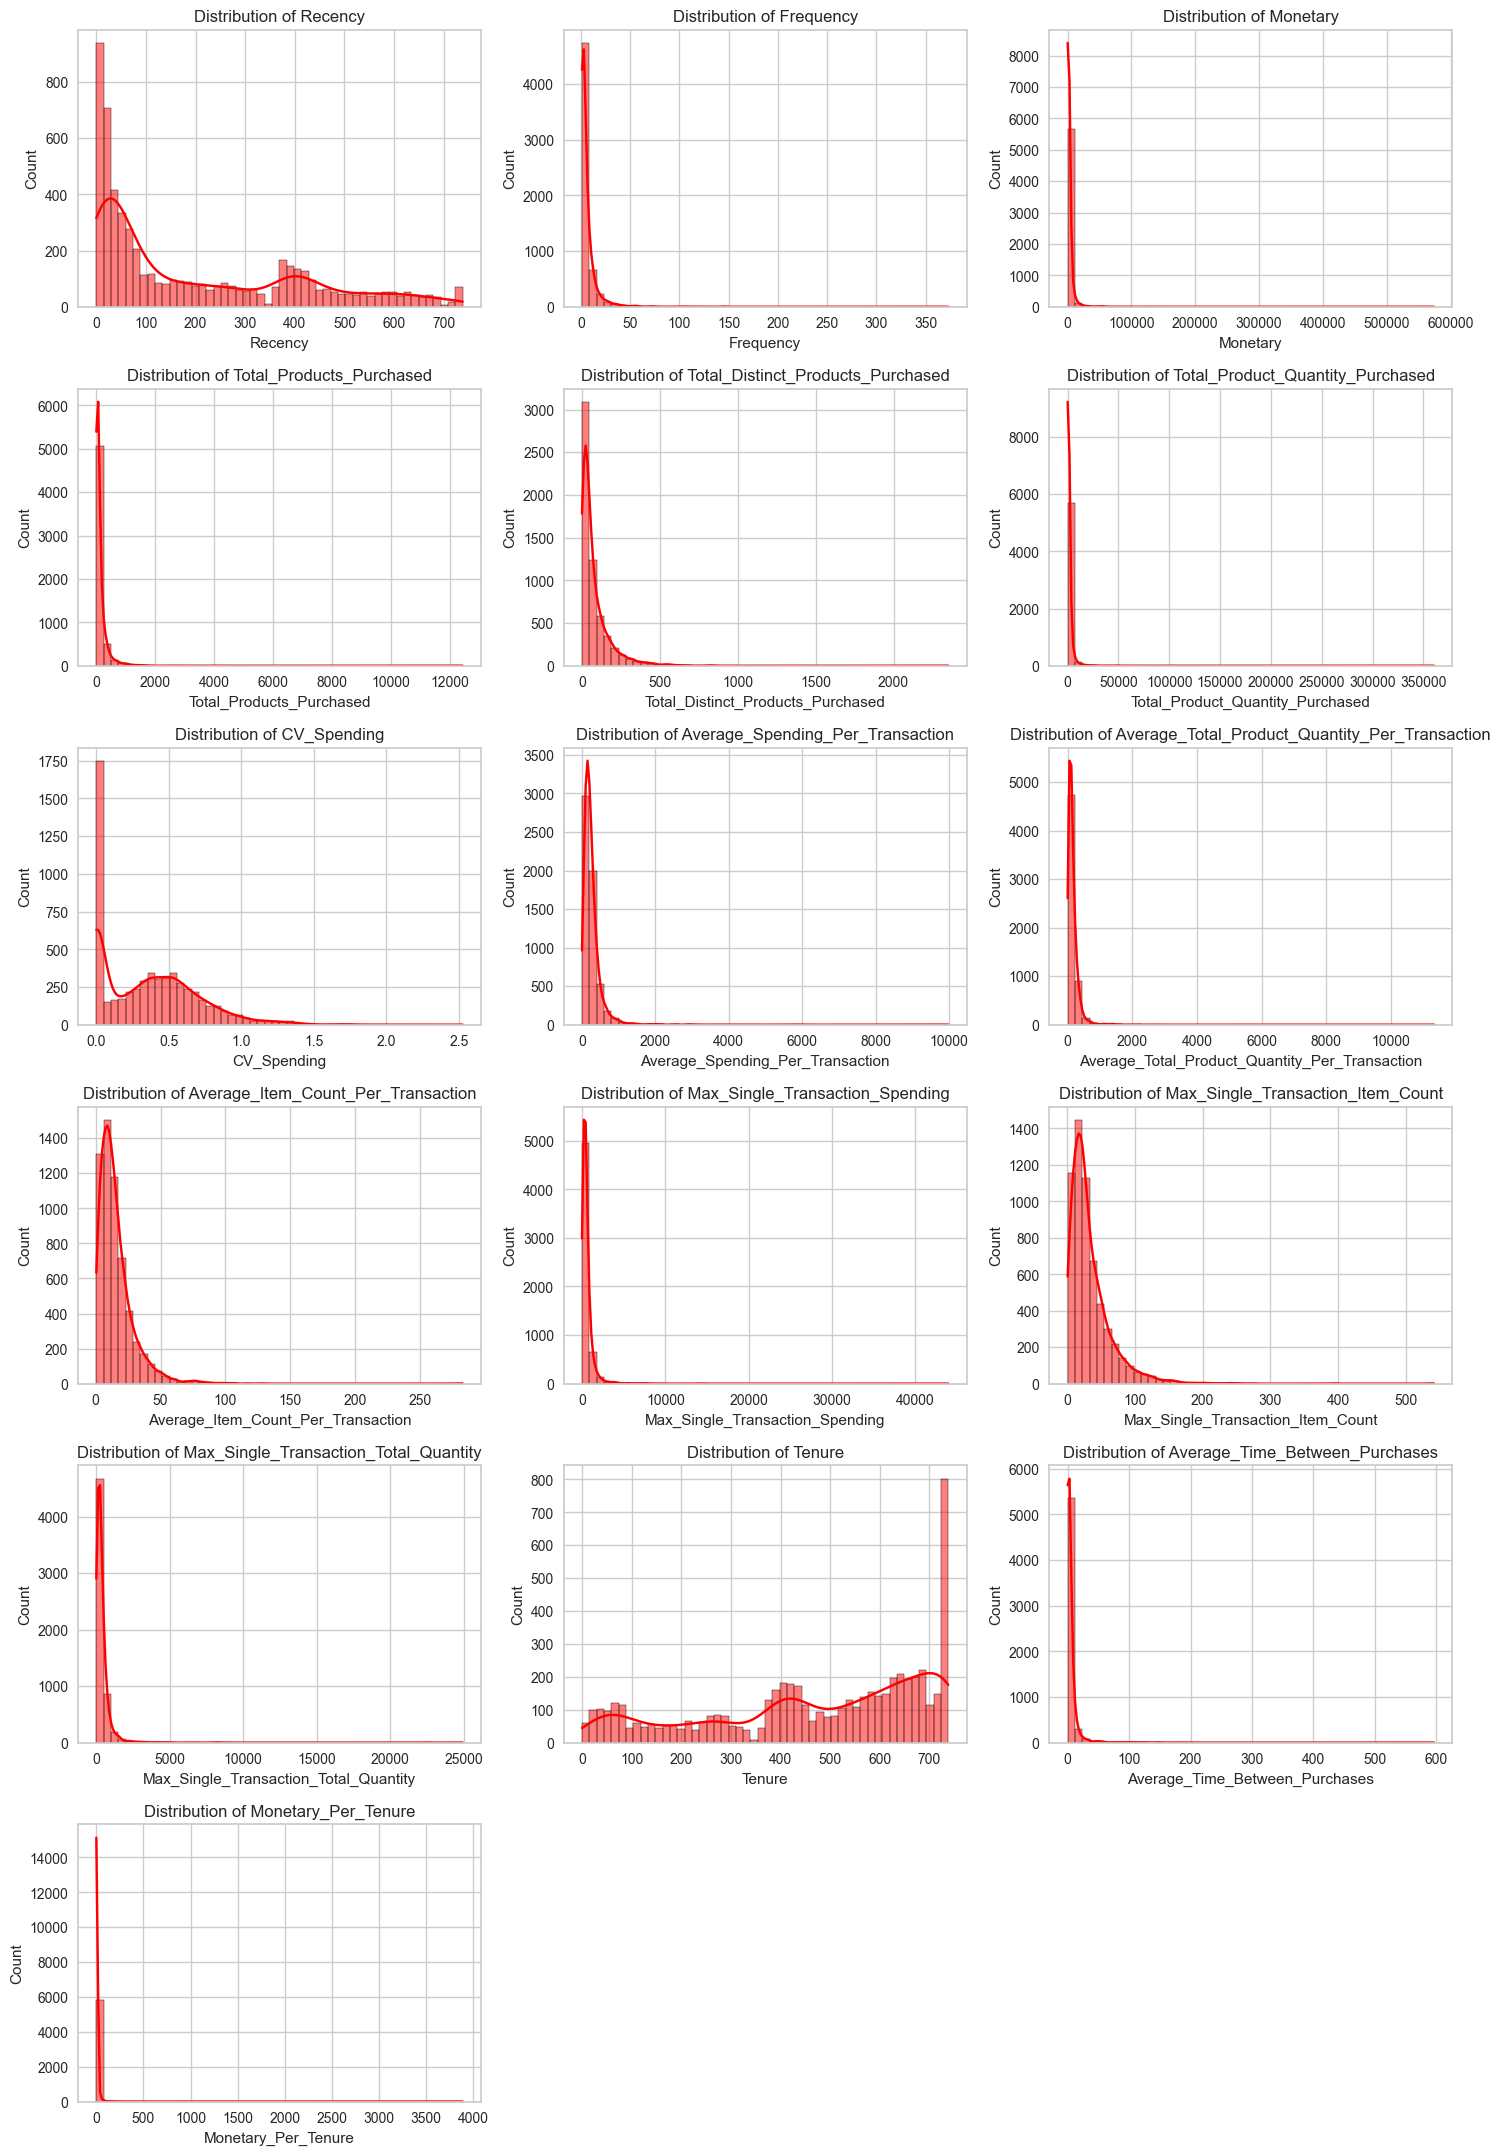

,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending,Average_Spending_Per_Transaction,Average_Total_Product_Quantity_Per_Transaction,Average_Item_Count_Per_Transaction,Max_Single_Transaction_Spending,Max_Single_Transaction_Item_Count,Max_Single_Transaction_Total_Quantity,Tenure,Average_Time_Between_Purchases,Monetary_Per_Tenure
count,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000
mean,199.198052,6.253247,2824.577961,132.702837,79.557416,1653.154477,0.359960,264.449934,159.895926,15.707154,608.129323,33.913363,389.712064,472.992310,5.242501,7.556070
std,208.509570,12.749286,13813.321562,341.300941,110.797891,7822.834355,0.330588,317.769807,246.963784,13.823129,1260.985630,31.151498,845.401022,223.203759,18.701904,57.203452
min,0.000000,1.000000,2.950000,1.000000,1.000000,1.000000,0.000000,1.475000,0.500000,0.500000,2.950000,1.000000,1.000000,0.000000,0.000000,0.004080
25%,24.000000,1.000000,339.575000,21.000000,18.000000,189.000000,0.000000,119.317500,63.068182,6.800000,230.467500,14.000000,127.000000,311.000000,0.000000,0.953538
50%,94.000000,3.000000,854.140000,52.000000,44.000000,484.500000,0.345568,198.454167,112.000000,12.333333,380.570000,25.000000,240.000000,528.000000,1.860122,2.426521
75%,378.000000,7.000000,2231.342500,138.000000,100.000000,1345.250000,0.573481,313.468125,194.666667,20.500000,650.775000,44.000000,435.000000,666.000000,4.828864,6.072274
max,738.000000,373.000000,573923.620000,12424.000000,2351.000000,360432.000000,2.525635,9979.125000,11329.500000,283.055556,43939.280000,541.000000,24938.000000,738.000000,596.000000,3885.420000


In [15]:
# Cek data statistik & plot sebelum log transform

features = [col for col in customer_data.columns]

plt.figure(figsize=(15, 50))

for i, col in enumerate(features, 1):
    plt.subplot(14, 3, i)
    sns.histplot(customer_data[col], kde=True, bins=50, color='red')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


# # Cek statistik sebelum log transform
display(customer_data.describe())

In [16]:
# Dari plot distribusi persebaran data tiap fitur, hampir semua grafik menunjukkan pola yang sangat miring ke kiri atau kanan (Skewed).

# Dampaknya ke clustering?
# - Clustering akan fokus Berfokus ke pelanggan dengan nilai ekstrem.
# - Cluster pelanggan biasa (majority customer) jadi tidak jelas / tersingkirkan

# Solusinya, lakukan transformasi pada semua fiturnya, jadi perbedaan jarak dengan data outlier tidak jauh.

# Contoh pakai log transform:
# Sebelum log transform: perbedaan antara 10 dan 1000 sangat jelas jaraknya sangat jauh
# Setelah pakai log transform: log(10)≈1 dan log(1000)≈3.2. --> jarak dari 1 dan 3.2 tidak terlalu jauh

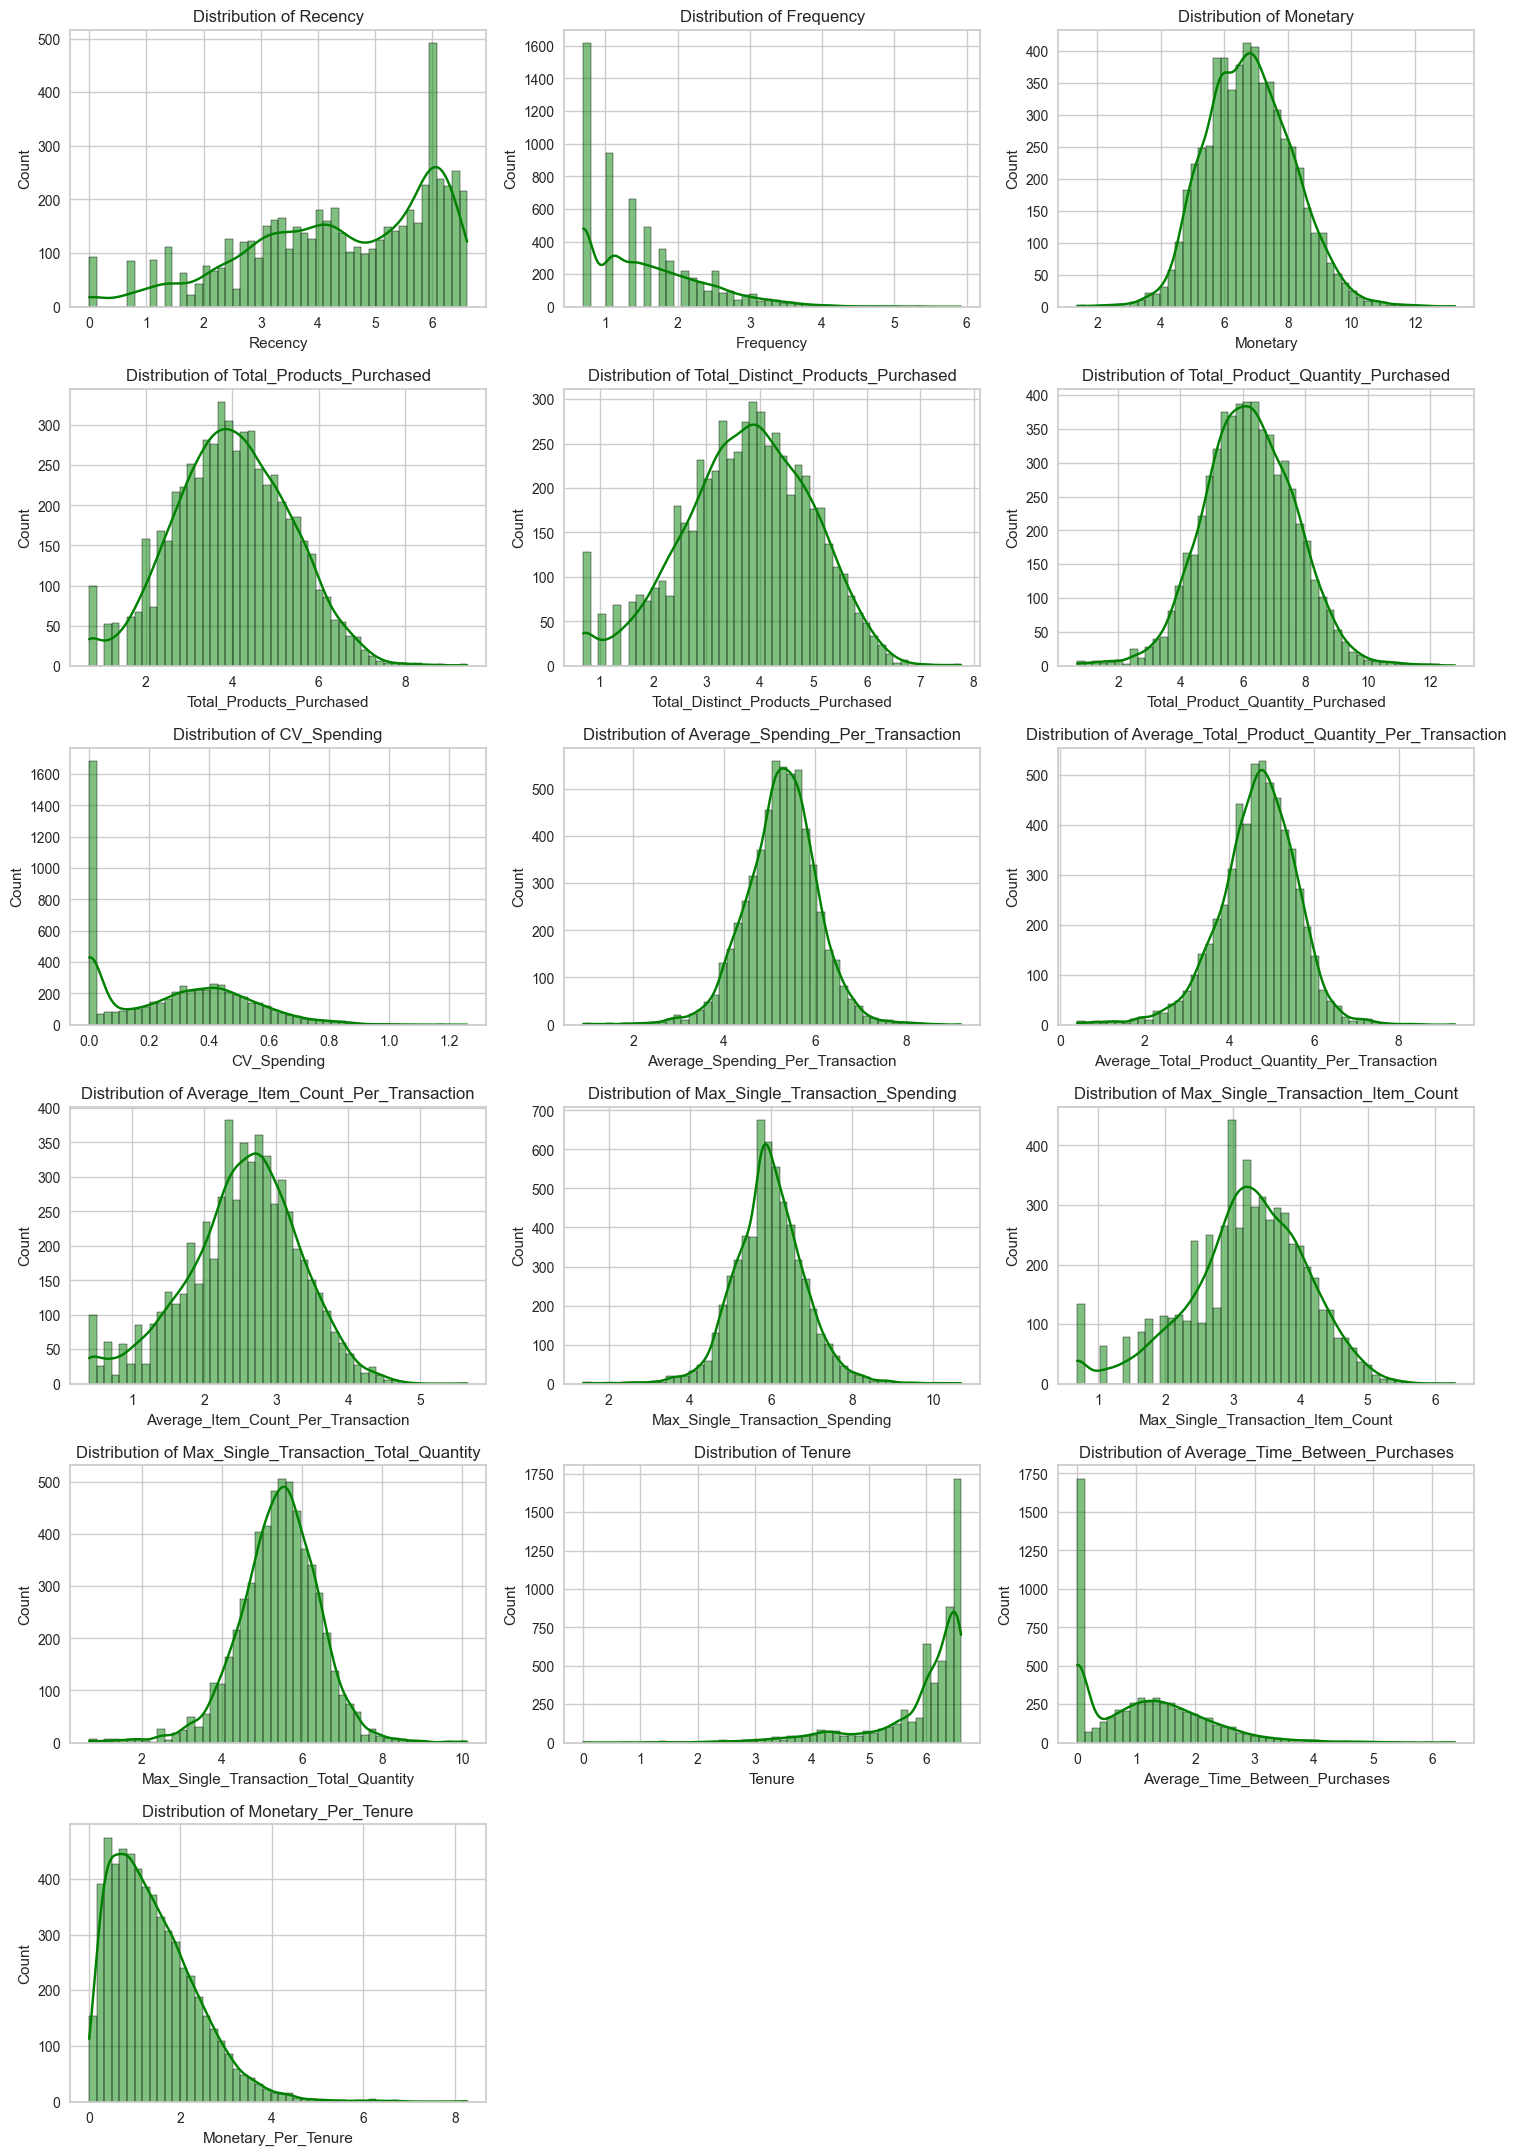

In [17]:
# Log Transform & Cek distribusi datanya

customer_data_log_transformed = customer_data.copy()

skewed_cols = [col for col in customer_data.columns]

for col in skewed_cols:
    customer_data_log_transformed[col] = np.log1p(customer_data_log_transformed[col])  # log(1+x)



# Visualisasi distribusi data

features = [col for col in customer_data_log_transformed.columns]

plt.figure(figsize=(15, 50))

for i, col in enumerate(features, 1):
    plt.subplot(14, 3, i)
    sns.histplot(customer_data_log_transformed[col], kde=True, bins=50, color='green')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


## Feature Scaling

In [18]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Copy the dataset
customer_data_scaled = customer_data_log_transformed.copy()

# Fit and transform the entire DataFrame at once
# Menggunakan .values untuk memastikan input adalah array NumPy
scaled_data = scaler.fit_transform(customer_data_scaled.values)

# Ganti nilai DataFrame asli dengan hasil yang diskalakan
customer_data_scaled = pd.DataFrame(scaled_data, columns=customer_data_scaled.columns, index=customer_data_scaled.index)

# Display the first few rows
display(customer_data_scaled.head())





,Recency,Frequency,Monetary,Total_Products_Purchased,Total_Distinct_Products_Purchased,Total_Product_Quantity_Purchased,CV_Spending,Average_Spending_Per_Transaction,Average_Total_Product_Quantity_Per_Transaction,Average_Item_Count_Per_Transaction,Max_Single_Transaction_Spending,Max_Single_Transaction_Item_Count,Max_Single_Transaction_Total_Quantity,Tenure,Average_Time_Between_Purchases,Monetary_Per_Tenure
Customer_ID,,,,,,,,,,,,,,,,
12346,0.876099,0.132505,0.443518,0.293663,0.357252,0.471450,0.618864,0.524802,0.516453,0.300462,0.539160,0.411020,0.600644,0.979872,0.417010,0.094266
12347,0.104938,0.287526,0.599658,0.539713,0.579126,0.603417,0.328785,0.650405,0.604230,0.541550,0.621754,0.567295,0.617591,0.908576,0.161385,0.311673
12348,0.653640,0.210015,0.508180,0.361448,0.357252,0.595750,0.354928,0.568436,0.639151,0.334500,0.548369,0.411020,0.682528,0.920809,0.344521,0.189039
12349,0.445769,0.132505,0.575177,0.510646,0.597865,0.553488,0.122515,0.712935,0.627283,0.644339,0.634492,0.642134,0.610130,0.965653,0.229405,0.239231
12350,0.868480,0.000000,0.362983,0.245018,0.302702,0.379284,0.000000,0.492926,0.469177,0.341697,0.463097,0.382010,0.486697,0.868480,0.000000,0.080327


## Feature Selection

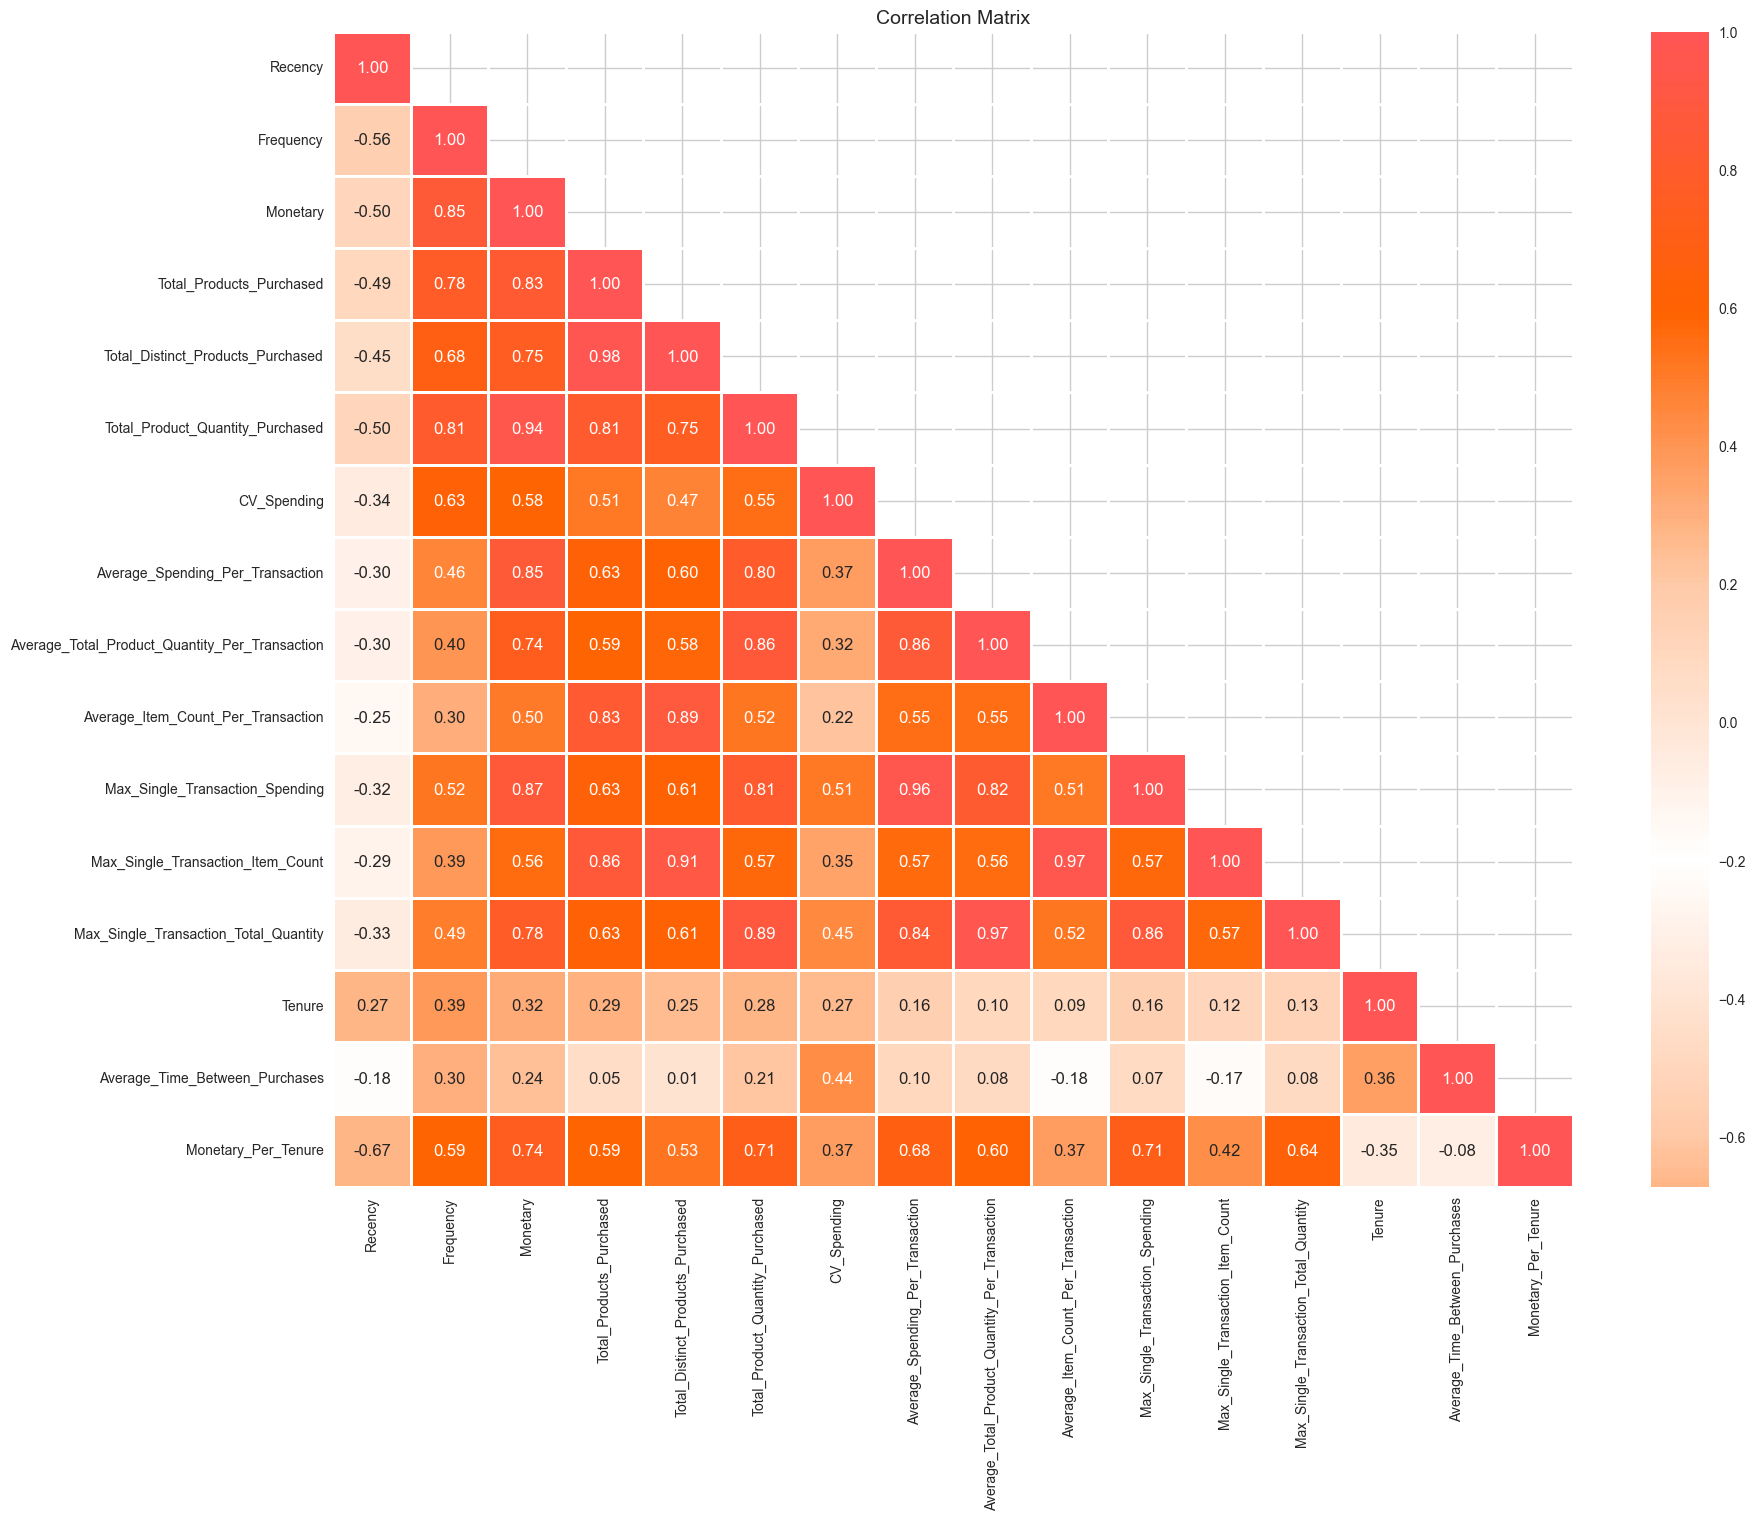

In [19]:
# Correlation Analysis

corr = customer_data_scaled.corr()

colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200', "#ff5555"]
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Create a mask to only show the lower triangle of the matrix (since it's mirrored around its top-left to bottom-right diagonal)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

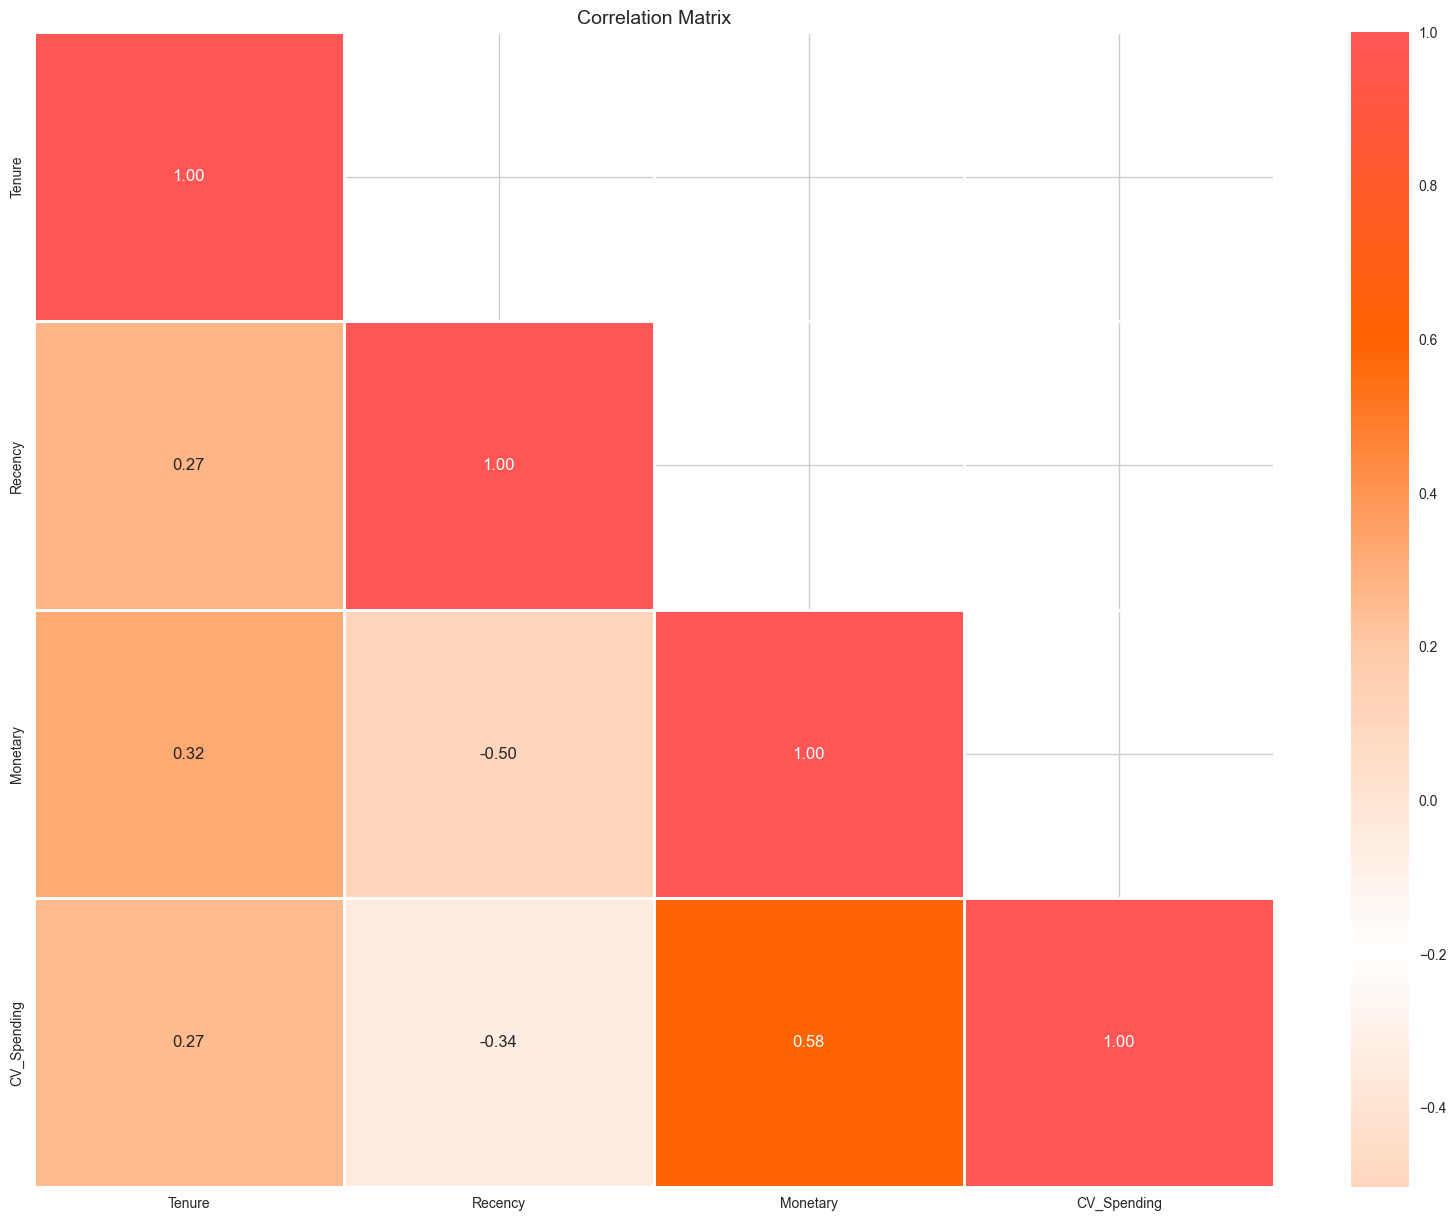

In [20]:
# Seleksi fitur-fitur dengan membuang yang redundan (korelasi linear tinggi > 0.7) atau yang tidak menghasilkan segmentasi yang kuat

customer_data_feature_reduction = customer_data_scaled[[ 
                                                'Tenure', 
                                                'Recency', 
                                                # 'Frequency',
                                                'Monetary',
                                                # 'Monetary_Per_Tenure',
                                                'CV_Spending',
                                                # 'Total_Product_Quantity_Purchased',
                                                # 'Total_Products_Purchased',
                                                # 'Total_Distinct_Products_Purchased', 
                                                # 'Average_Spending_Per_Transaction', 
                                                # 'Average_Item_Count_Per_Transaction', 
                                                # 'Average_Total_Product_Quantity_Per_Transaction',
                                                # 'Average_Time_Between_Purchases',
                                                # 'Max_Single_Transaction_Item_Count', 
                                                # 'Max_Single_Transaction_Spending',  
                                                # 'Max_Single_Transaction_Total_Quantity',
                                                ]]

# Correlation Analysis

# Calculate the correlation matrix excluding the 'CustomerID' column
corr = customer_data_feature_reduction.corr()



# Define a custom colormap
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200', "#ff5555"]
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Create a mask to only show the lower triangle of the matrix (since it's mirrored around its 
# top-left to bottom-right diagonal)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()


## Dimensionality Reduction

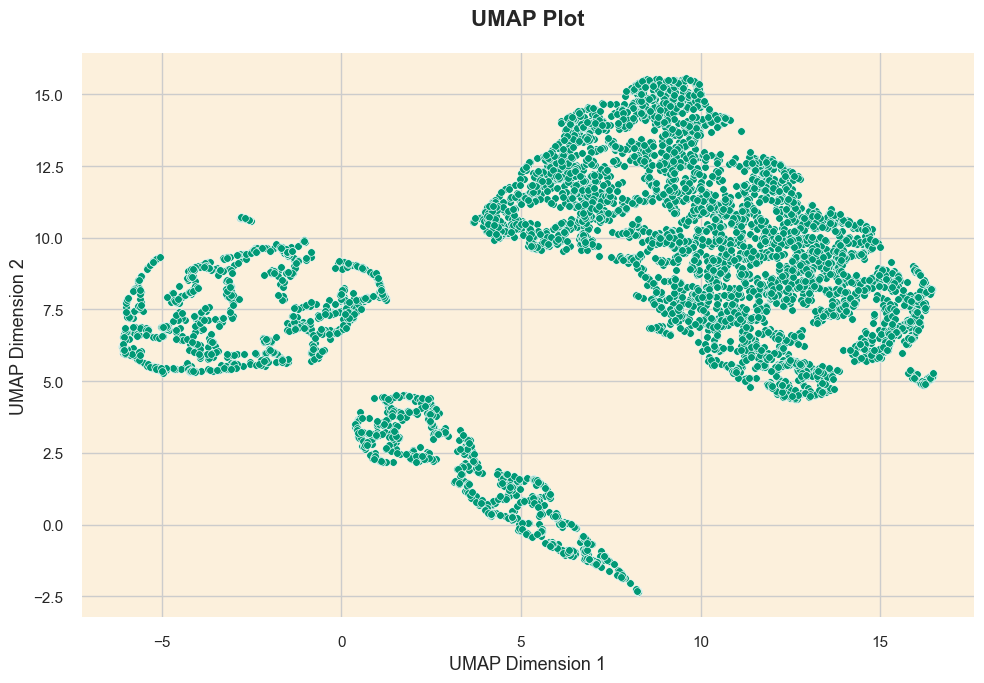

In [21]:
# UMAP Dimensionality Reduction
def umap_dimensionality_reduction(df, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        n_components=2,
        random_state=random_state
    )
    embedding = reducer.fit_transform(df)

    embedding_df = pd.DataFrame(
        embedding,
        columns=["UMAP_1", "UMAP_2"],
        index=df.index
    )

    return embedding_df

# Visualisasi hasil UMAP

def plot_umap(df, labels=None, palette = ['#e8000b', '#1ac938', '#023eff', '#ff6200', '#c00acc', '#81387d', "#828502", "#03B7FF", "#BE7B00"]):
    # Setup tema visual
    sns.set(style="whitegrid", rc={"axes.facecolor": "#fcf0dc"})

    # Plot
    plt.figure(figsize=(10, 7))
    if labels is not None:
        sns.scatterplot(
            x=df[:, 0],
            y=df[:, 1],
            hue=labels,
            palette=palette,
            s=30,
        )
        plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    else:
        sns.scatterplot(
            x=df[:, 0],
            y=df[:, 1],
            s=30,
            color="#009975",
        )
    
    # Tata letak
    plt.title("UMAP Plot", fontsize=16, weight='bold', pad=20)
    plt.xlabel("UMAP Dimension 1", fontsize=13)
    plt.ylabel("UMAP Dimension 2", fontsize=13)
    plt.tight_layout()
    sns.despine(left=True, bottom=True)
    plt.show()

# UMAP Dimensionality Reduction (3D)
def umap_dimensionality_reduction_3d(df, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        n_components=3,
        random_state=random_state
    )
    embedding = reducer.fit_transform(df)

    embedding_df = pd.DataFrame(
        embedding,
        columns=["UMAP_1", "UMAP_2", "UMAP_3"],
        index=df.index
    )

    return embedding_df

import plotly.express as px

def plot_umap_3d(df, labels=None, palette=None):
    if palette is None:
        palette = ['#e8000b', '#1ac938', '#023eff', '#ff6200', '#c00acc', '#81387d', "#828502", "#03B7FF", "#BE7B00"]

    if isinstance(df, pd.DataFrame):
        x, y, z = df["UMAP_1"], df["UMAP_2"], df["UMAP_3"]
    else:
        x, y, z = df[:, 0], df[:, 1], df[:, 2]

    if labels is not None:
        fig = px.scatter_3d(
            x=x, y=y, z=z,
            color=labels.astype(str),
            color_discrete_sequence=palette,
            opacity=0.8,
            title="3D UMAP Projection"
        )
    else:
        fig = px.scatter_3d(
            x=x, y=y, z=z,
            color_discrete_sequence=["#009975"],
            opacity=0.8,
            title="3D UMAP Projection"
        )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        scene=dict(
            xaxis_title='UMAP Dimension 1',
            yaxis_title='UMAP Dimension 2',
            zaxis_title='UMAP Dimension 3'
        ),
        template='plotly_white',
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()




customer_data_umap = umap_dimensionality_reduction(customer_data_feature_reduction)
plot_umap(customer_data_umap.values)

# Jalankan reduksi dimensi 3D
umap_3d_df = umap_dimensionality_reduction_3d(customer_data_feature_reduction)

# Visualisasikan hasil cluster KMeans di ruang 3D
plot_umap_3d(umap_3d_df)


# Clustering

In [22]:
# Function untuk Evaluate Model
def evaluate_clustering_model(df_without_label, clusters):
    if len(np.unique(clusters)) < 2:
        sil_score = np.nan
        calinski_score = np.nan
        davies_score = np.nan
    else:
        sil_score = silhouette_score(df_without_label, clusters)
        calinski_score = calinski_harabasz_score(df_without_label, clusters)
        davies_score = davies_bouldin_score(df_without_label, clusters)
    
    n_clusters = len(set(clusters))
    
    evaluation_df = pd.DataFrame({
        "Metric": ["Number of Observations", "Number of Clusters", "Silhouette Score", "Calinski Harabasz Score", "Davies Bouldin Score"],
        "Value": [len(df_without_label), n_clusters, sil_score, calinski_score, davies_score]
    })

    return evaluation_df


## K-Means Clustering

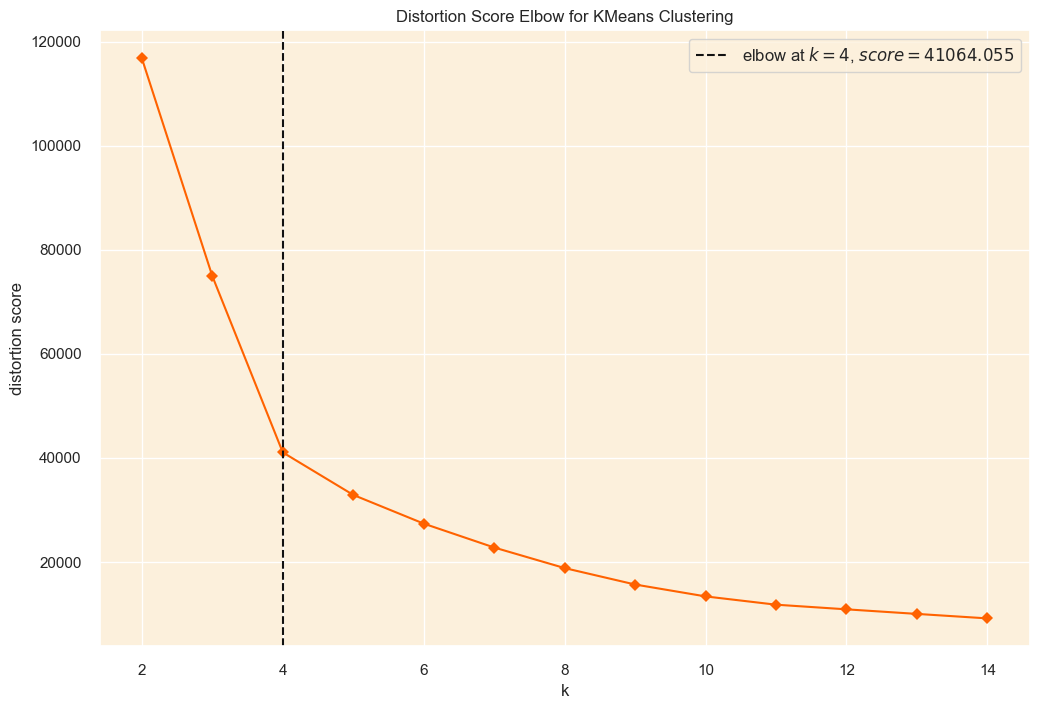

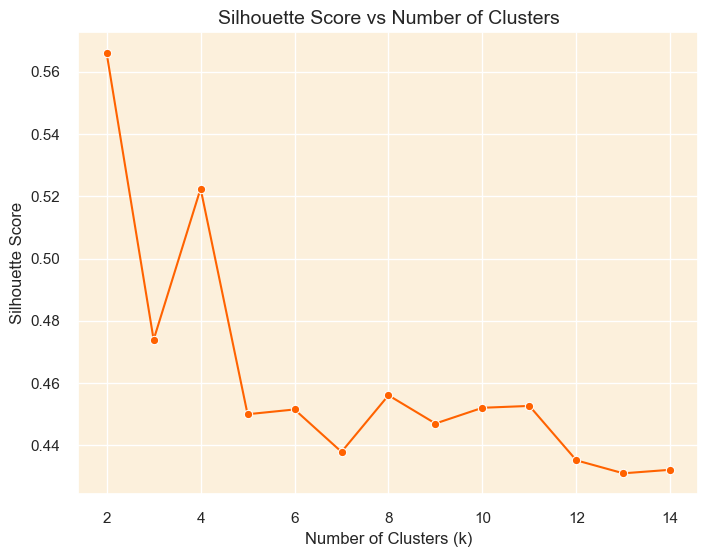

In [23]:
# Cari jumlah cluster (k) yang optimal, bisa pakai 2 cara, elbow method, dan silhouette method

# Elbow Method
def plotElbow(original_df):
    sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})
    sns.set_palette(['#ff6200'])
    
    km = KMeans(n_init=40, max_iter=300, random_state=0)

    fig, ax = plt.subplots(figsize=(12, 8))
    visualizer = KElbowVisualizer(km, k=(2, 15), timings=False, ax=ax)
    visualizer.fit(original_df)
    visualizer.show()

# Silhouette Method
def plotSilhouette(original_df):
    silhouette_scores = []
    k_range = range(2, 15)

    for k in k_range:
        kmeans_model = KMeans(
            n_clusters=k, n_init=40, max_iter=300, random_state=0
        )
        kmeans_model.fit(original_df)
        score = silhouette_score(original_df, kmeans_model.labels_)
        silhouette_scores.append(score)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.lineplot(x=list(k_range), y=silhouette_scores, marker="o", color="#ff6200")
    plt.title("Silhouette Score vs Number of Clusters", fontsize=14)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.show()


plotElbow(customer_data_umap)
plotSilhouette(customer_data_umap)


,Metric,Value
0,Number of Observations,5852.000000
1,Number of Clusters,4.000000
2,Silhouette Score,0.522484
3,Calinski Harabasz Score,11063.235352
4,Davies Bouldin Score,0.661781


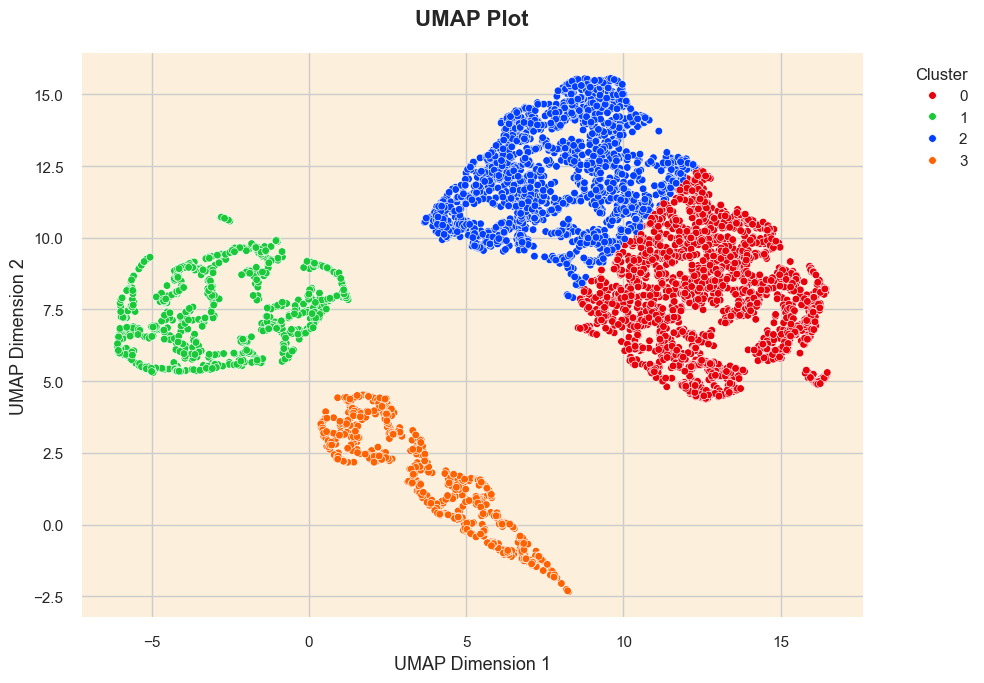

In [24]:
def kMeansClustering(original_df, optimal_k):

    kmeans = KMeans(init ='k-means++',
                    n_clusters=optimal_k,
                    random_state=0,
                    n_init=40,
                    max_iter=300)
    
    kmeans.fit(original_df)

    if isinstance(original_df, np.ndarray):
        clustered_df = pd.DataFrame(original_df, columns=[f"Feature_{i+1}" for i in range(original_df.shape[1])])
    else:
        clustered_df = original_df.copy()
    
    
    clustered_df['Cluster'] = kmeans.labels_

    return clustered_df


kMeans_df = kMeansClustering(customer_data_umap, 4)
kMeans_eval_df = evaluate_clustering_model(customer_data_umap, kMeans_df['Cluster'])
display(kMeans_eval_df)
plot_umap(kMeans_df.values[:, :-1], kMeans_df['Cluster'])
# plot_umap_3d(umap_3d_df, labels=kMeans_df['Cluster'])
# plot_umap_clusters(customer_data_feature_reduction, kMeans_df['Cluster'])

kmeans_3d = KMeans(init ='k-means++',
                    n_clusters=4,
                    random_state=0,
                    n_init=40,
                    max_iter=300)
labels_kmeans_3d = kmeans_3d.fit_predict(umap_3d_df)

plot_umap_3d(umap_3d_df, labels_kmeans_3d)

## Gaussian Mixture Model Clustering

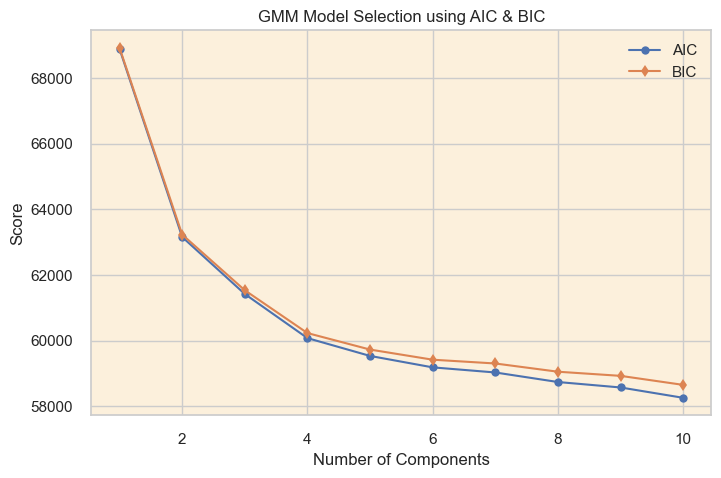

,log_likelihood,BIC,AIC
0,-30018.019531,60235.553454,60082.039062


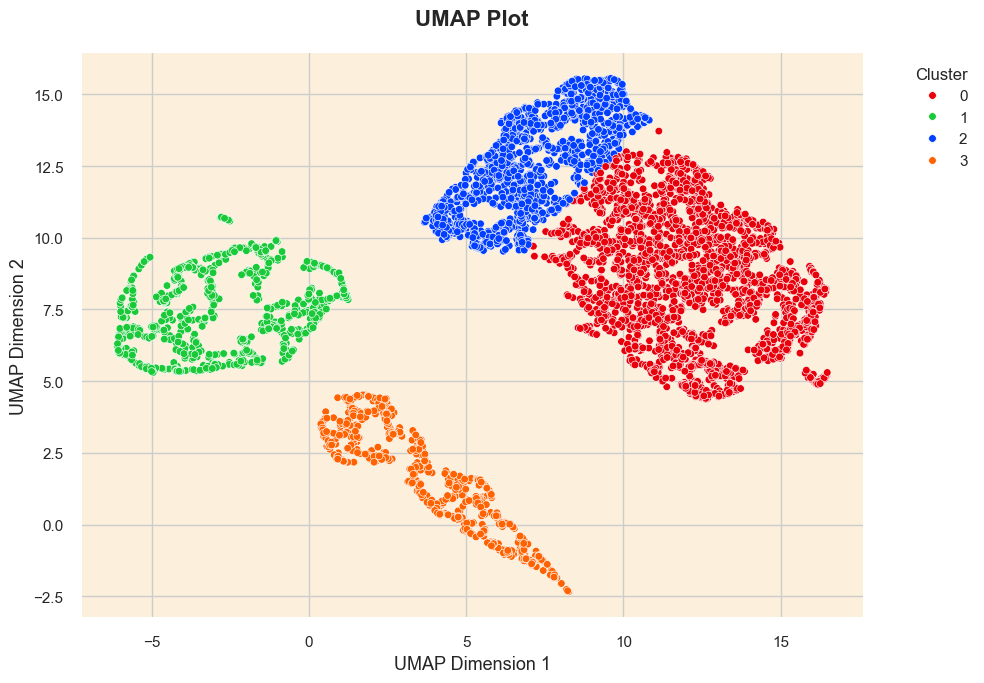

,Cluster_0_Prob,Cluster_1_Prob,Cluster_2_Prob,Cluster_3_Prob
Customer_ID,,,,
12346,4.931017e-02,6.653436e-12,9.506896e-01,0.000000
12347,1.000000e+00,1.104105e-19,5.951702e-28,0.000000
12348,9.996024e-01,1.527163e-09,3.973871e-04,0.000000
12349,1.000000e+00,3.179922e-11,4.029440e-11,0.000000
12350,5.248193e-09,5.431041e-03,2.674193e-05,0.994542


,Metric,Value
0,Number of Observations,5852.000000
1,Number of Clusters,4.000000
2,Silhouette Score,0.506136
3,Calinski Harabasz Score,9993.685547
4,Davies Bouldin Score,0.660598


In [25]:
from sklearn.mixture import GaussianMixture

# Plot AIC dan BIC untuk pemilihan jumlah komponen optimal
def plot_aic_bic(X, max_clusters=10, random_state=42):
    n_components = range(1, max_clusters + 1)
    aic = []
    bic = []

    for n in n_components:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type='full',
            random_state=random_state,
            n_init=50,
            init_params='kmeans'
        )
        gmm.fit(X)
        aic.append(gmm.aic(X))
        bic.append(gmm.bic(X))

    plt.figure(figsize=(8,5))
    plt.plot(n_components, aic, marker='o', label='AIC')
    plt.plot(n_components, bic, marker='d', label='BIC')
    plt.xlabel('Number of Components')
    plt.ylabel('Score')
    plt.title('GMM Model Selection using AIC & BIC')
    plt.legend()
    plt.show()


def gmmClustering(original_df, n_components):
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=42,
        n_init=50,
        init_params= 'kmeans'
    )
    gmm.fit(original_df)

    labels = gmm.predict(original_df)
    probs = gmm.predict_proba(original_df)

    if isinstance(original_df, np.ndarray):
        clustered_df = pd.DataFrame(original_df, columns=[f"Feature_{i+1}" for i in range(original_df.shape[1])])
    else:
        clustered_df = original_df.copy()
    
    clustered_df['Cluster'] = labels
    clustered_df['Probability'] = probs.max(axis=1)

    # Probabilitas keanggotaan di tiap cluster
    probs = gmm.predict_proba(original_df)
    probs_df = pd.DataFrame(probs, columns=[f'Cluster_{i}_Prob' for i in range(n_components)], index=clustered_df.index)

    # Hitung metrik evaluasi
    log_likelihood = gmm.score(original_df) * original_df.shape[0]
    bic = gmm.bic(original_df)
    aic = gmm.aic(original_df)

    metrics_df = pd.DataFrame({
        'log_likelihood': [log_likelihood],
        'BIC': [bic],
        'AIC': [aic]
    })

    return clustered_df, probs_df, metrics_df


# Plot
plot_aic_bic(customer_data_umap, max_clusters=10)

# Jalankan GMM berdasarkan hasil plot AIC & BIC
gmm_df , gmm_probs_df, gmm_eval_metrics = gmmClustering(customer_data_umap, n_components=4)

## Log Likelihood
display(gmm_eval_metrics)

# Visualisasi
plot_umap(customer_data_umap.values, gmm_df['Cluster'])

# Tampilkan beberapa baris probabilitas pelanggan berada di semua kluster
display(gmm_probs_df.head())

# Evaluasi hasil
gmm_eval_df = evaluate_clustering_model(customer_data_umap, gmm_df['Cluster'])
display(gmm_eval_df)


In [26]:
gmm_3d = GaussianMixture(
        n_components=4,
        covariance_type='full',
        random_state=42,
        n_init=50,
        init_params= 'kmeans'
    )
labels_3d = gmm_3d.fit_predict(umap_3d_df)

plot_umap_3d(umap_3d_df, labels_3d)

# Cluster Profiles

In [27]:
COLORS = ['#e8000b', '#1ac938', '#023eff', '#ff6200', '#c00acc', '#81387d', "#828502", "#03B7FF", "#BE7B00"]

def plot_radar_clusters(features, cluster_col='Cluster', colors=COLORS, ncols=2, figsize=(20, 6)):


    # Hitung centroid per cluster
    cluster_centroids = features.groupby(cluster_col).mean()

    # Radar chart setup
    labels = np.array(cluster_centroids.columns)
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    labels = np.concatenate((labels, [labels[0]]))
    angles += angles[:1]

    # Dapatkan batas global untuk semua plot
    global_min = cluster_centroids.min().min()
    global_max = cluster_centroids.max().max()

    # Subplot
    num_clusters = len(cluster_centroids)
    rows = (num_clusters + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows=rows, ncols=ncols,
        figsize=(figsize[0], figsize[1] * rows),
        subplot_kw=dict(polar=True)
    )
    axes = axes.flatten()

    # Plot tiap cluster
    for i, cluster in enumerate(cluster_centroids.index):
        data = cluster_centroids.loc[cluster].tolist()
        data += data[:1]
        color = colors[i % len(colors)] if colors else f"C{i}"
        ax = axes[i]
        ax.fill(angles, data, color=color, alpha=0.4)
        ax.plot(angles, data, color=color, linewidth=2)
        ax.set_title(f"Cluster {cluster}", size=16, color=color, y=1.1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels[:-1], fontsize=9)
        ax.set_ylim(global_min, global_max)  # <<— Samakan skala di sini

    # Hapus subplot kosong
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [28]:
def plot_bar_clusters(features, cluster_col='Cluster', colors=COLORS, ncols=2, figsize=(20, 6)):
    cluster_centroids = features.groupby(cluster_col).mean()

    # Ubah ke format long agar mudah di-plot
    melted = cluster_centroids.reset_index().melt(id_vars=cluster_col, var_name='Feature', value_name='Mean Value')

    # Setup subplot
    num_clusters = cluster_centroids.shape[0]
    rows = (num_clusters + ncols - 1) // ncols
    fig, axes = plt.subplots(rows, ncols, figsize=(figsize[0], figsize[1] * rows))
    axes = axes.flatten()

    # Plot tiap cluster
    for i, cluster in enumerate(cluster_centroids.index):
        ax = axes[i]
        subset = melted[melted[cluster_col] == cluster]
        color = colors[i % len(colors)] if colors else f"C{i}"

        sns.barplot(
            data=subset,
            x='Feature',
            y='Mean Value',
            color=color,
            ax=ax
        )

        ax.set_title(f"Cluster {cluster}", fontsize=14, color=color)
        ax.set_xlabel('')
        ax.set_ylabel('Mean Value')
        ax.tick_params(axis='x', rotation=45)

    # Hapus subplot kosong
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


### K-Means

In [29]:
# Summary
features = customer_data_feature_reduction.columns.values

kmeans_profile = customer_data[features]
kmeans_profile['Cluster'] = kMeans_df['Cluster']

cluster_summary = kmeans_profile.groupby('Cluster').agg(['mean', 'median', 'count'])
display(cluster_summary)

Tenure                  Recency                  Monetary  \
               mean median count        mean median count         mean   
Cluster                                                                  
0        470.303651  525.0  2246   24.374443   19.0  2246  5496.948958   
1        526.542735  519.0   936  524.477564  513.0   936   334.891303   
2        580.083678  619.5  1936  271.185950  240.0  1936  1861.663089   
3        130.467302   87.5   734  129.475477   87.5   734   361.913992   

                        CV_Spending                  
           median count        mean    median count  
Cluster                                              
0        1839.455  2246    0.502653  0.481358  2246  
1         223.945   936    0.000755  0.000000   936  
2        1054.985  1936    0.504229  0.472143  1936  
3         242.395   734    0.000858  0.000000   734

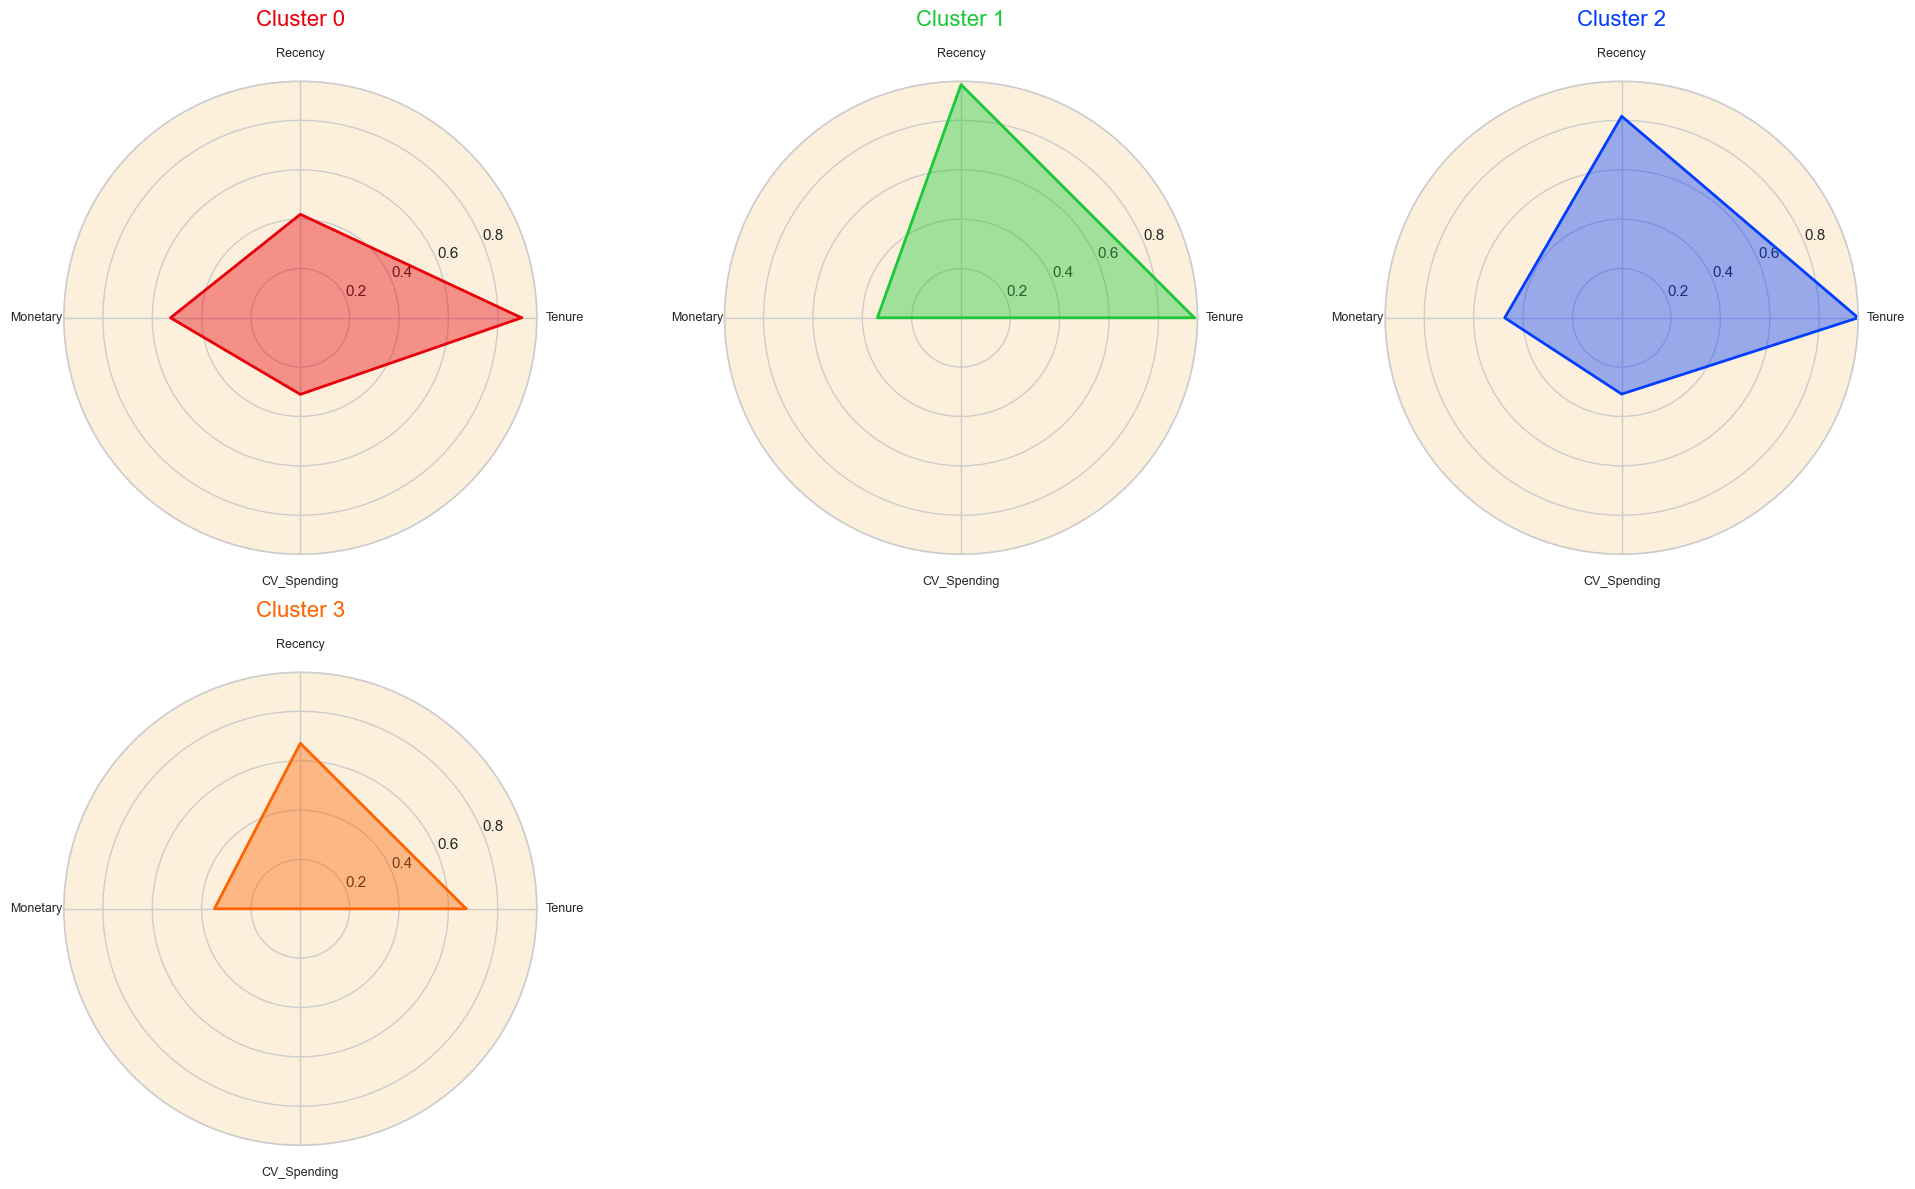

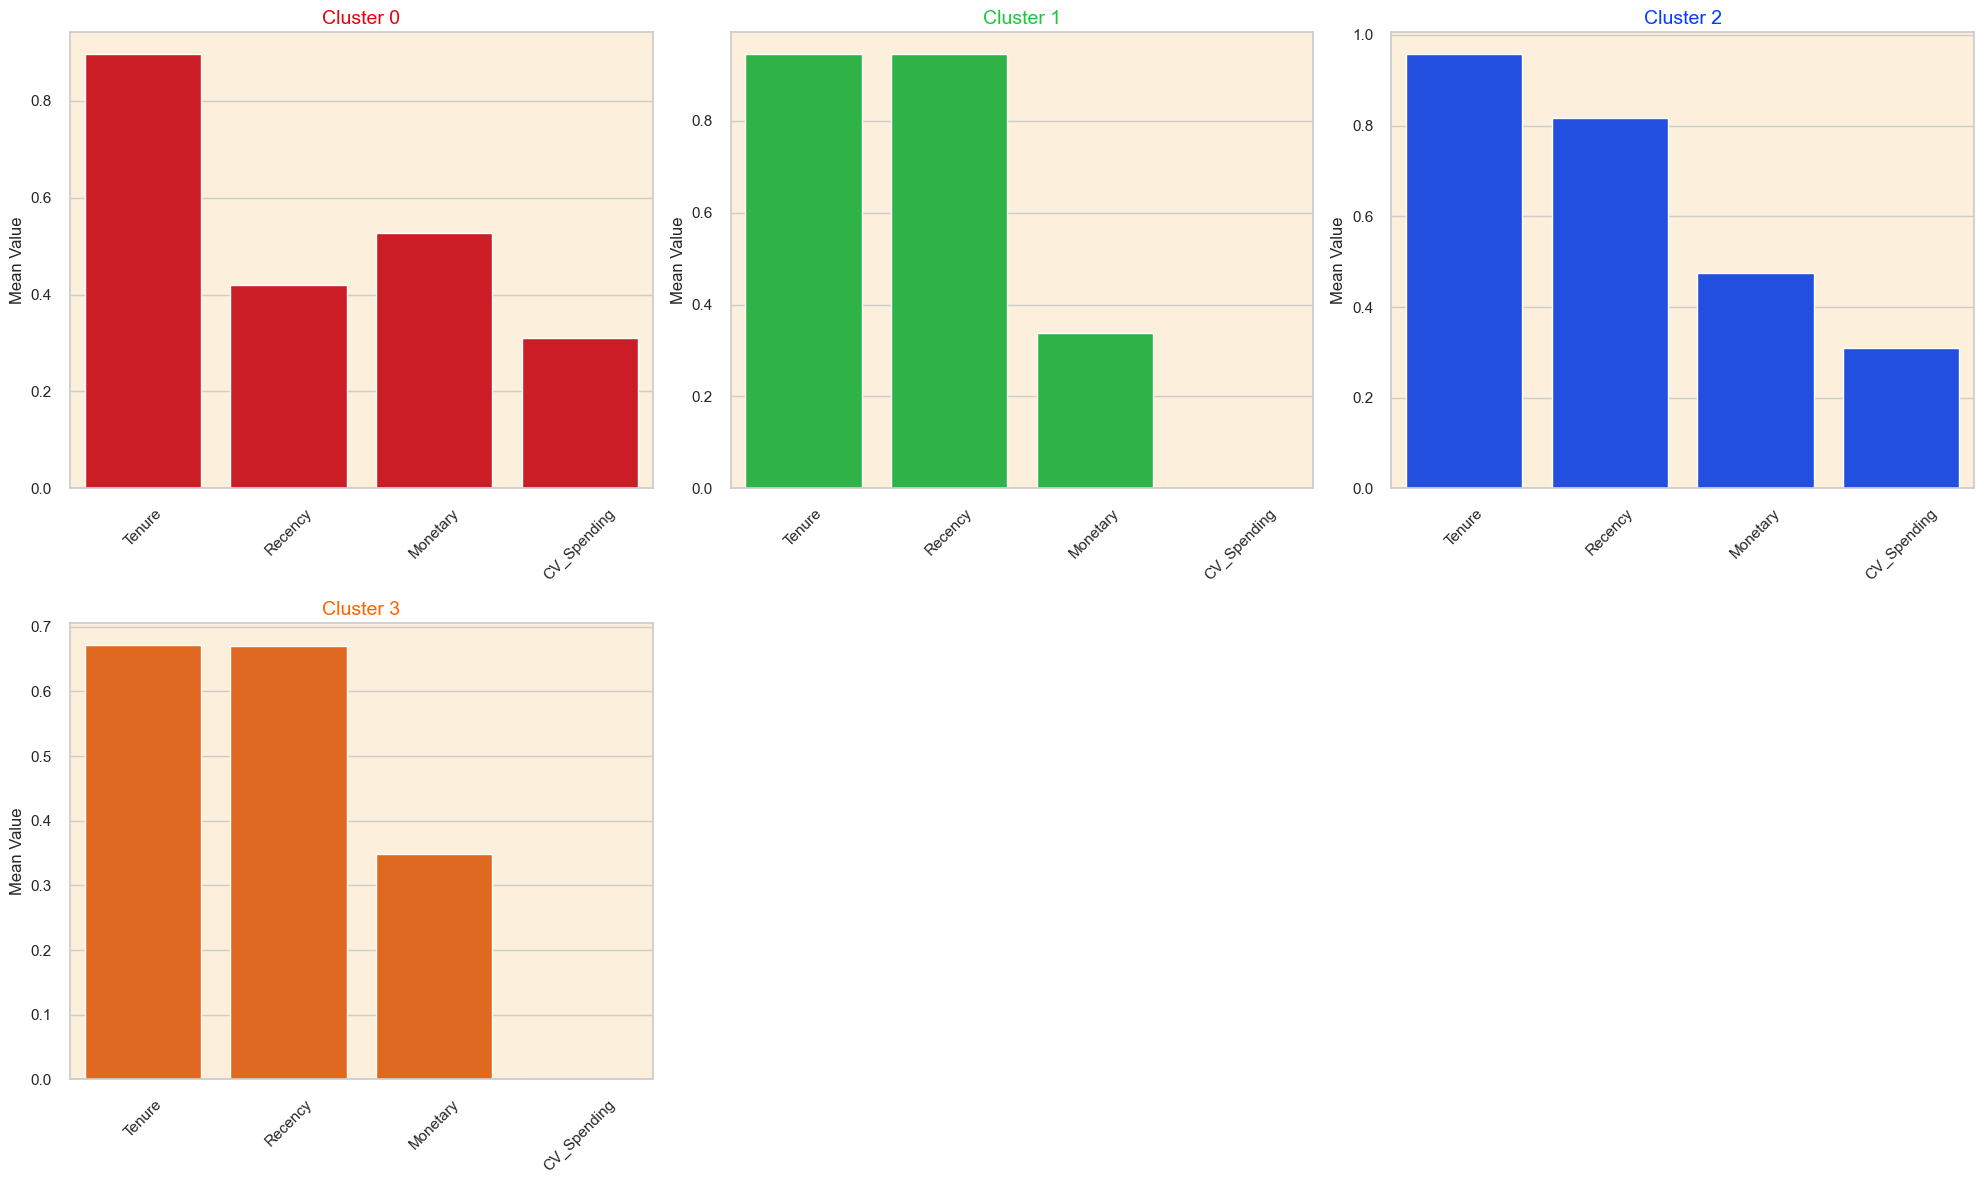

In [30]:
# Plot Cluster Profiles

kmeans_profile_scaled = customer_data_feature_reduction
kmeans_profile_scaled['Cluster'] = kMeans_df['Cluster']

plot_radar_clusters(kmeans_profile_scaled, cluster_col='Cluster', ncols=3)
plot_bar_clusters(kmeans_profile_scaled, cluster_col='Cluster', ncols=3)

### Gaussian Mixture Model (GMM)

In [31]:
# Summary
features = customer_data_feature_reduction.columns.values

gmm_profile = customer_data_feature_reduction[features]
gmm_profile['Cluster'] = gmm_df['Cluster']

cluster_summary = gmm_profile.groupby('Cluster').agg(['mean', 'median', 'count'])
display(cluster_summary)

Tenure                   Recency                  Monetary  \
             mean    median count      mean    median count      mean   
Cluster                                                                 
0        0.908418  0.959087  2782  0.469528  0.493255  2782  0.527049   
1        0.945184  0.946790   936  0.944576  0.945033   936  0.339121   
2        0.957163  0.971576  1400  0.869016  0.890275  1400  0.452438   
3        0.671845  0.678696   734  0.670828  0.678696   734  0.348368   

                        CV_Spending                  
           median count        mean    median count  
Cluster                                              
0        0.522366  2782    0.313669  0.314391  2782  
1        0.340060   936    0.000582  0.000000   936  
2        0.449222  1400    0.303166  0.291101  1400  
3        0.346692   734    0.000667  0.000000   734

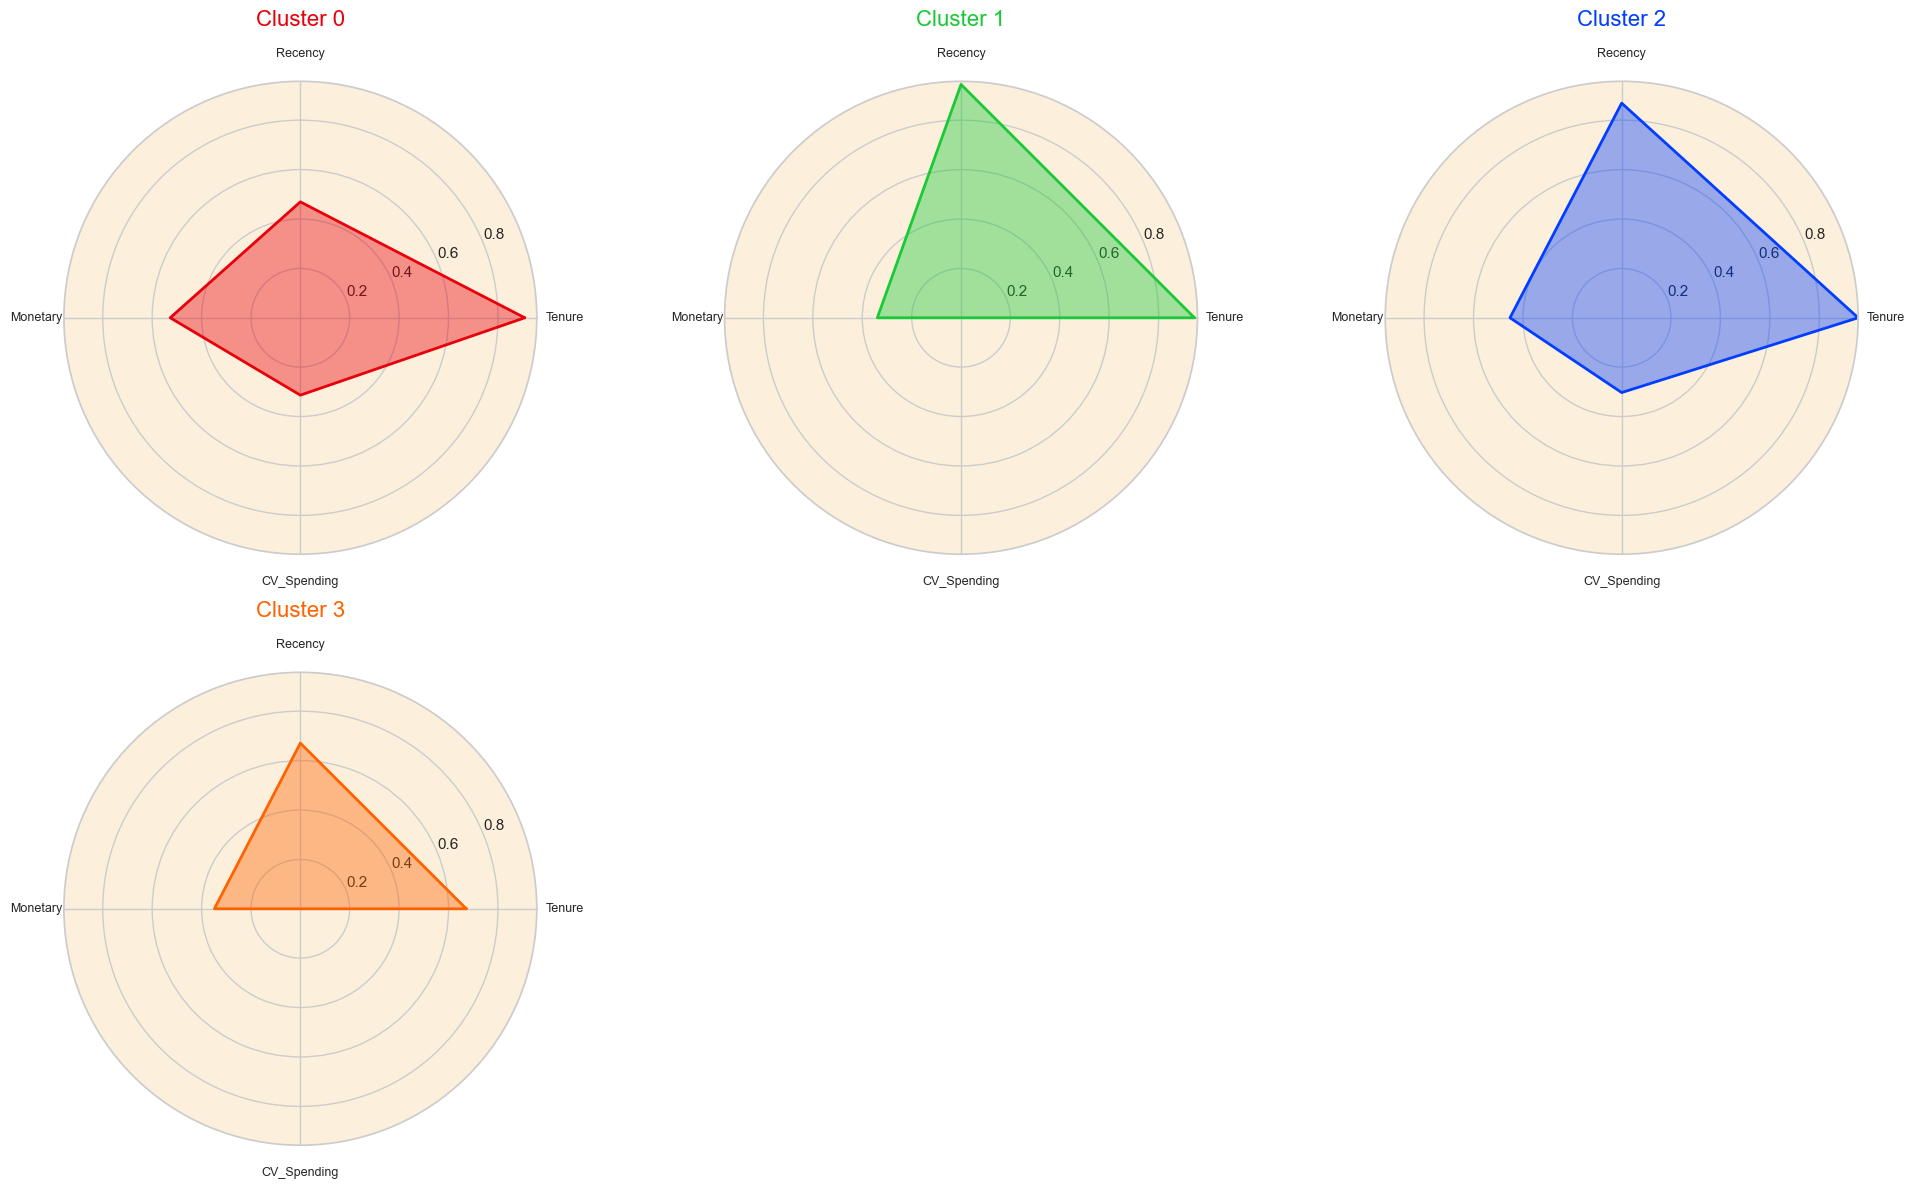

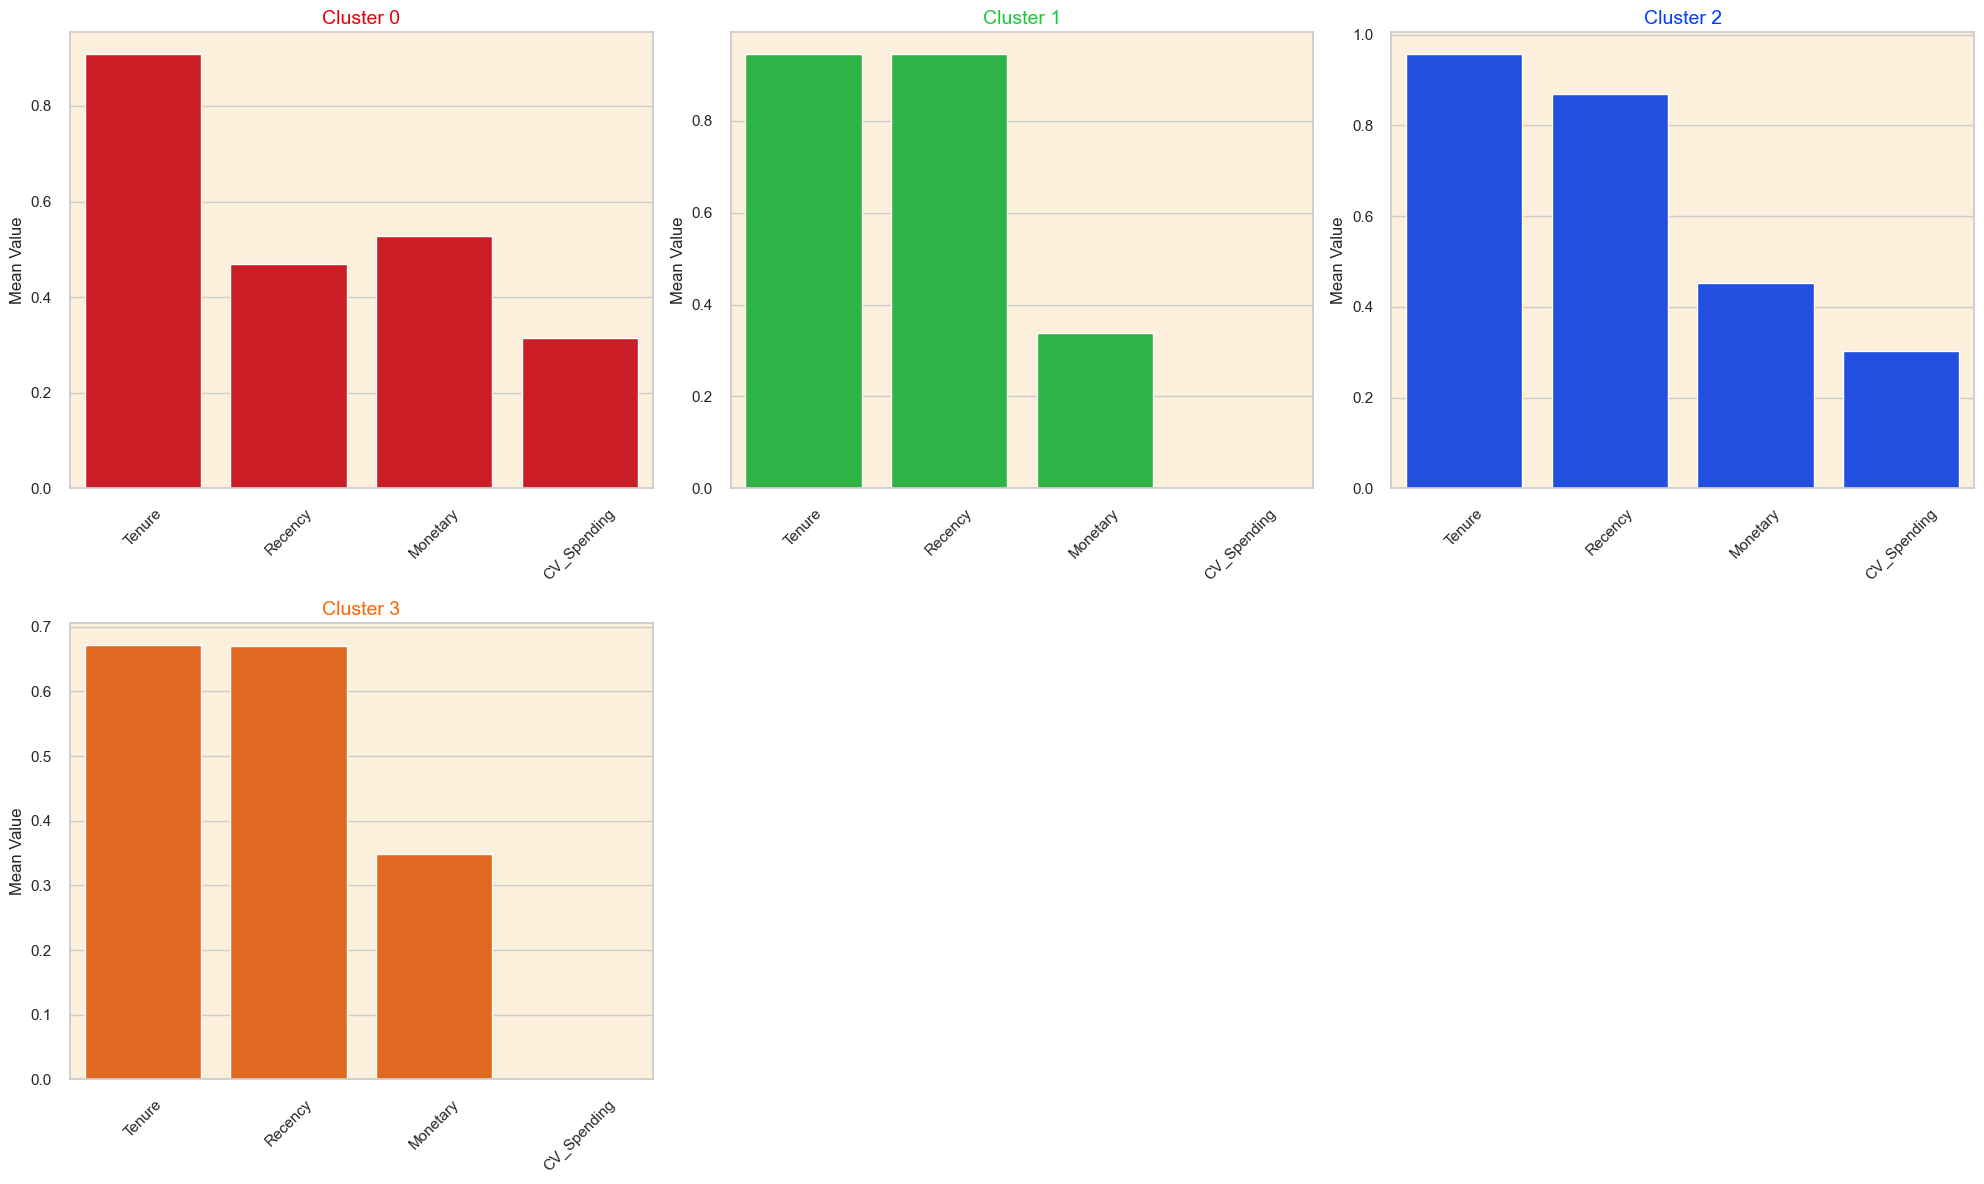

In [32]:
# Plot Cluster Profiles

gmm_profile_scaled = customer_data_feature_reduction[features]
gmm_profile_scaled['Cluster'] = gmm_df['Cluster']

plot_radar_clusters(gmm_profile_scaled, cluster_col='Cluster', ncols=3)
plot_bar_clusters(gmm_profile_scaled, cluster_col='Cluster', ncols=3)

In [33]:
# display(gmm_df)

# Explainable AI (XAI)

In [34]:
# Karena ini unsupervised learning, XAI tujuannya bukan untuk memahami bagaimana model bisa memprediksi satu titik tertentu, tapi fokusnya ke kenapa satu kelompok titik (cluster) berbeda dengan kelompok lainnya

# Tujuannya:
# - Memahami fitur yang membedakan tiap cluster
# - Mengetahui kontribusi tiap fitur terhadap hasil cluster

## SHAP 

### Supervised Model Training

In [35]:
# Pakai Model Random Forest
def train_random_forest_model(X, y):
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X, y)
    return rf

In [36]:
# Train Model

X = customer_data_feature_reduction.copy().drop(columns=['Cluster'])  # input

# Target K-Means
y_kmeans = kMeans_df['Cluster']

# Target GMM
y_gmm = gmm_df['Cluster']


# Surrogate model untuk K-Means
rf_kmeans = train_random_forest_model(X, y_kmeans)

# Surrogate model untuk GMM
rf_gmm = train_random_forest_model(X, y_gmm)


In [37]:
rf_gmm.classes_

array([0, 1, 2, 3])

In [38]:
# Explain Model

def shap_explain(rf_model, X):

    # buat explainer SHAP
    explainer = shap.TreeExplainer(rf_model)

    # hitung nilai SHAP
    shap_values = explainer.shap_values(X)
    
    # Summary plot bar
    shap.summary_plot(shap_values, X, plot_type="bar", show=True, plot_size= (14,8))
    
    # Violin
    shap.summary_plot(shap_values, X, plot_type="violin", show=False)
    fig = plt.gcf()
    fig.set_size_inches(35,12)
    plt.show()


    return shap_values



In [39]:
df_check = X.copy()
df_check["cluster"] = y_gmm

df_check.groupby("cluster").mean()

,Tenure,Recency,Monetary,CV_Spending
cluster,,,,
0,0.908418,0.469528,0.527049,0.313669
1,0.945184,0.944576,0.339121,0.000582
2,0.957163,0.869016,0.452438,0.303166
3,0.671845,0.670828,0.348368,0.000667


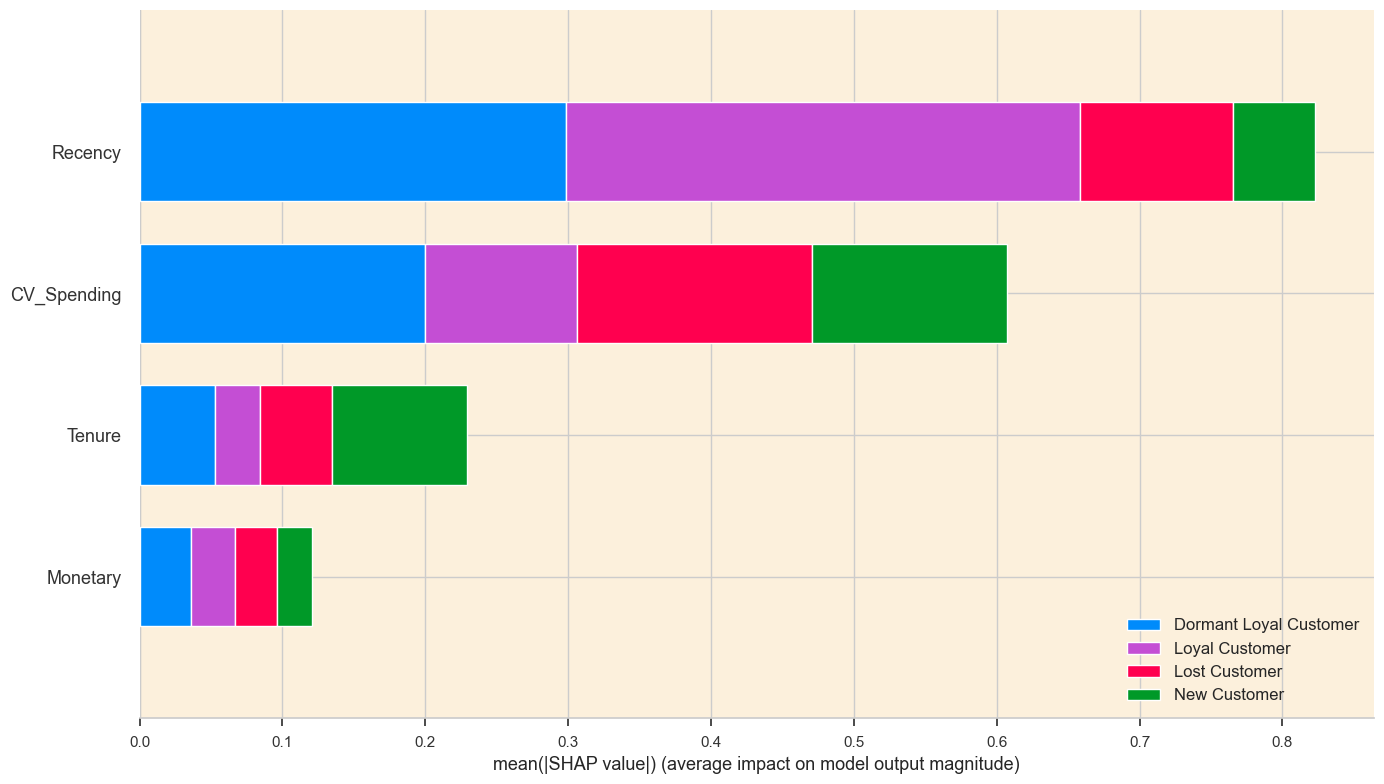

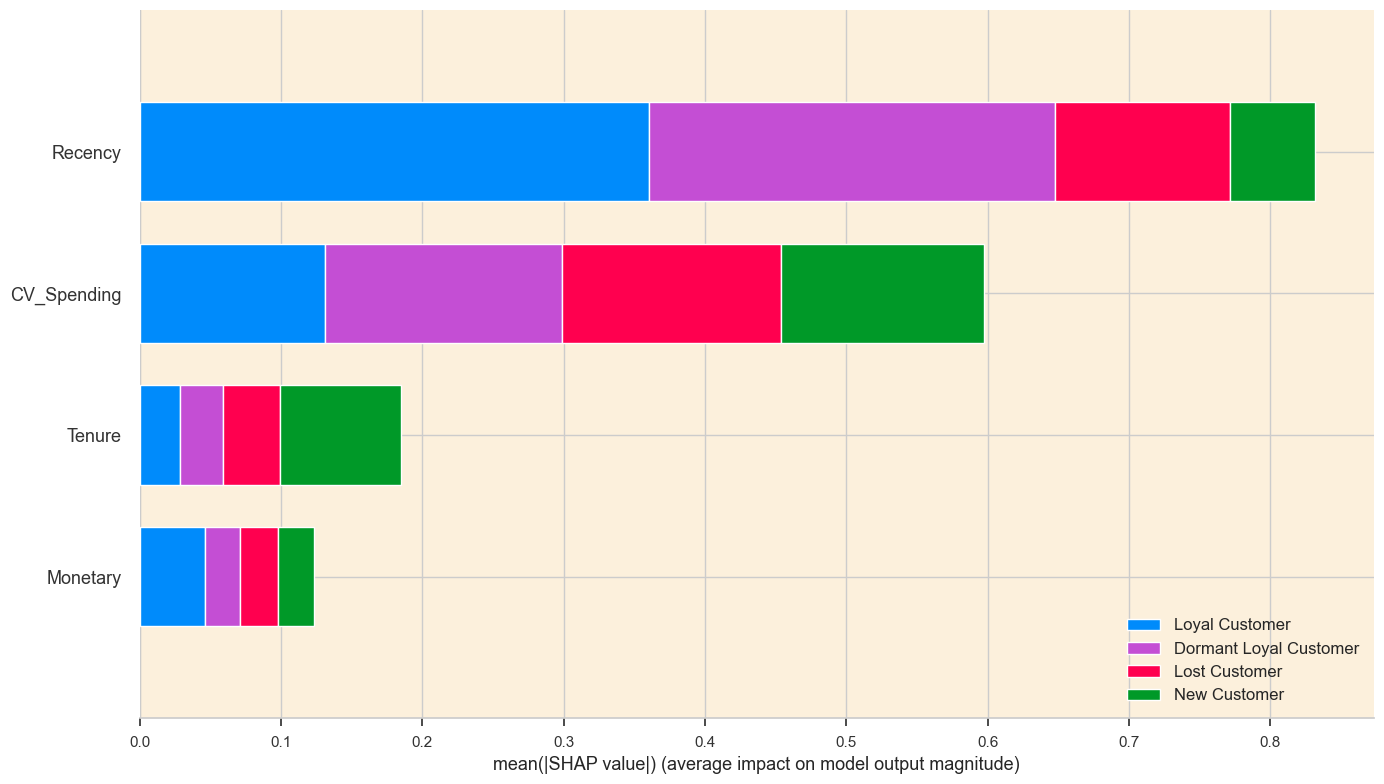

In [40]:
def shap_explain_mapped(rf_model, X, cluster_name_map, title_suffix=""):

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X)

    # Ambil urutan class dari model
    class_order = rf_model.classes_

    # Bangun nama class berbasis mapping bisnis
    class_names = [cluster_name_map[i] for i in class_order]

    # BAR PLOT (GLOBAL IMPORTANCE)
    shap.summary_plot(
        shap_values,
        X,
        plot_type="bar",
        class_names=class_names,
        show=True,
        plot_size=(14, 8)
    )

    return shap_values


cluster_name_map = {
    0: "Loyal Customer",
    1: "Lost Customer",
    2: "Dormant Loyal Customer",
    3: "New Customer"
}

# SHAP K-Means with business labels
shap_values_kmeans = shap_explain_mapped(
    rf_kmeans,
    X,
    cluster_name_map,
    title_suffix="(K-Means Clusters)"
)

# GMM SHAP with business labels
shap_values_gmm = shap_explain_mapped(
    rf_gmm,
    X,
    cluster_name_map,
    title_suffix="(GMM Clusters)"
)
